# GH Copilot in Action for APIM & AI Foundry — Backend Pool Load Balancing

This notebook walks through the  deployment of Azure API Management (APIM) as an AI Gateway in front of multiple Azure AI Foundry (Azure OpenAI–compatible) endpoints using APIM's **built-in backend pool** feature with **priority-based routing**.

## Overview: How It Works

- APIM exposes a single inference endpoint to clients.

- A backend pool groups **four** AI Foundry deployments across two different regions at **three priority levels**.

- The **Priority 1** backend (PTU DZ in Sweden Central) receives all traffic under normal conditions.
- When it returns **HTTP 429** (rate-limited), APIM's `retry` policy transparently retries against the pool — the two **Priority 2** backends (PayGo DZ in Sweden Central and PayGo DZ in Germany West Central) each receive ~50% of the overflowed traffic, balanced by `weight`.
- If all Priority 2 backends are also exhausted, traffic falls to the **Priority 3** backend (PayGo Global in Germany West Central) as a last resort.
- Only if **all backends are unavailable** does APIM return **HTTP 503** to the caller.
- **Objective is to reflect no 429 errors to the clients.**

## Recommended Architecture

```
Caller (Python SDK / HTTP client)
        Caller (Python SDK / HTTP client)
                │
                ▼
          Azure API Management (Basicv2 tier)
          ┌──────────────────────────────────────────────────────────┐
          │  Inference API  /inference/openai/...                    │
          │  Policy:                                                 │
          │    • set-backend-service → backend pool                  │
          │    • retry on 429 / 503 (count=2, tries all backends)    │
          └───────┬──────────────────────────────────────────────────┘
                  │
                  ▼
           ┌─────────────────────────────────────────────┐
           │  Backend Pool (priority + weighted routing) │
           │                                             │
           │  ┌─────────────────────────────────────┐   │
           │  │ Priority 1                          │   │  ← served first
           │  │ PTU DZ - swedencentral              │   │
           │  └─────────────────────────────────────┘   │
           │                                             │
           │  ┌──────────────────┐ ┌──────────────────┐ │
           │  │ Priority 2 w=50  │ │ Priority 2 w=50  │ │  ← 50/50 on P1 failover
           │  │ PayGo DZ         │ │ PayGo DZ         │ │
           │  │ swedencentral    │ │ germanywestcent  │ │
           │  └──────────────────┘ └──────────────────┘ │
           │                                             │
           │  ┌─────────────────────────────────────┐   │
           │  │ Priority 3                          │   │  ← last resort
           │  │ PayGo Global Germany West           │   │
           │  └─────────────────────────────────────┘   │
           └─────────────────────────────────────────────┘
```

> ⚠️ **WARNING:** The demo architecture will include only **PayGo** deployments of **gpt-4o-mini** due to limitations in the Sandbox environment.

## Demo Architecture

```
Caller (Python SDK / HTTP client)
        Caller (Python SDK / HTTP client)
                │
                ▼
          Azure API Management (Basicv2 tier)
          ┌──────────────────────────────────────────────────────────┐
          │  Inference API  /inference/openai/...                    │
          │  Policy:                                                 │
          │    • set-backend-service → backend pool                  │
          │    • retry on 429 / 503 (count=2, tries all backends)    │
          └───────┬──────────────────────────────────────────────────┘
                  │
                  ▼
           ┌─────────────────────────────────────────────┐
           │  Backend Pool (priority + weighted routing) │
           │                                             │
           │  ┌─────────────────────────────────────┐   │
           │  │ Priority 1                          │   │  ← served first
           │  │ PTU DZ - swedencentral              │   │
           │  └─────────────────────────────────────┘   │
           │                                             │
           │  ┌──────────────────┐ ┌──────────────────┐ │
           │  │ Priority 2 w=50  │ │ Priority 2 w=50  │ │  ← 50/50 on P1 failover
           │  │ PayGo DZ         │ │ PayGo DZ         │ │
           │  │ swedencentral    │ │ germanywestcent  │ │
           │  └──────────────────┘ └──────────────────┘ │
           │                                             │
           │  ┌─────────────────────────────────────┐   │
           │  │ Priority 3                          │   │  ← last resort
           │  │ PayGo Global Germany West           │   │
           │  └─────────────────────────────────────┘   │
           └─────────────────────────────────────────────┘
```

## Step 0: Prerequisites

Complete this section before running any code cells.

### Required Tools

| Tool | Version | Install |
|------|---------|---------|
| Python | 3.12+ | [python.org](https://www.python.org/downloads/) |
| VS Code | Latest | [code.visualstudio.com](https://code.visualstudio.com/) |
| VS Code Jupyter extension | Latest | [Marketplace](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.jupyter) |
| Azure CLI | Latest | `curl -sL https://aka.ms/InstallAzureCLIDeb \| sudo bash` |
| Git | Any | `sudo apt install git` |

> **Azure CLI must be signed in** before deployment steps. Run `az login` first.
> The first setup code cell in **Step 1** creates `.venv`, installs dependencies, and registers the notebook kernel.

### Azure Permissions

Your account needs **both** on the target subscription or resource group:
- `Contributor` — to create resources
- `RBAC Administrator` (or `Owner`) — to assign RBAC roles to the APIM managed identity

> **Why?** The APIM system-assigned managed identity must be granted the **Cognitive Services OpenAI User** role on each AI Foundry account so it can obtain Entra ID tokens for authentication.

### Azure Regions with Model Availability

All regions must support the model you intend to deploy. Verify availability at:
[Azure OpenAI models by region](https://learn.microsoft.com/azure/ai-services/openai/concepts/models)

Regions used in this lab: `swedencentral`, `germanywestcentral`.

---

## Step 0a: Verify Prerequisites (CLI Checklist)

Run the commands below in a terminal to verify all prerequisites are installed. Install any missing tools before proceeding.

### ✓ Python 3.12+

```bash
python --version
# Expected: Python 3.12.x or higher
```

### ✓ Azure CLI

```bash
az --version
# Expected: azure-cli version 2.60.0 or higher
```

If not installed:
```bash
pip install azure-cli
```

Then sign in:
```bash
az login
```

### ✓ Git

```bash
git --version
# Expected: git version 2.x or higher
```

### ✓ VS Code & Jupyter Extension

```bash
code --version
# Expected: version 1.x or higher
```

Install the Jupyter extension:
- Open VS Code
- Press `Ctrl+Shift+X` (Windows/Linux) or `Cmd+Shift+X` (macOS)
- Search for "Jupyter"
- Click **Install**

### ✓ Azure Permissions

Verify you're logged into the right subscription:

```bash
az account show --query "{User:user.name, Subscription:name}" -o table
```

Your account needs **Contributor** and **RBAC Administrator** roles on the target subscription.

---

Ready? Proceed to **Step 1**.

---

## Step 1: Create venv and Install Local Dependencies

> **First-time kernel selection:** When you run the cell below, VS Code will ask you to choose a kernel. Pick **Python 3** (the default system interpreter). This is only used to bootstrap the virtual environment — you will switch to the `.venv` kernel in Step 2.

This repository is self-contained for this lab. No external repository clone is required.

Expected layout after this step:
```
/workspaces/
└── from-specs-to-mission-critical-deployments/
    ├── main.bicep
    ├── modules/                 ← local Bicep modules
    ├── shared/                  ← local Python helpers
    ├── policy.xml
    └── .venv/                   ← created by this step
```

This step will:
1. Create `.venv` from the system Python
2. Install `requirements.txt` into `.venv`

Run the setup code below:

In [ ]:
import subprocess
import os
import sys

# From your demo repo root
repo_root = os.getcwd()
print(f"Working from: {repo_root}\n")

# --- 1. Create virtual environment ---
print("1. Creating virtual environment...")
venv_path = os.path.join(repo_root, ".venv")
result = subprocess.run(
    [sys.executable, "-m", "venv", venv_path],
    capture_output=True,
    text=True
)
if result.returncode != 0:
    print(f"❌ Failed to create .venv:\n{result.stderr}")
    raise SystemExit("Cannot continue without .venv")

venv_python = os.path.join(venv_path, "bin", "python")
if not os.path.isfile(venv_python):
    print(f"❌ Expected venv python at {venv_python} but it does not exist.")
    raise SystemExit("Cannot continue without .venv/bin/python")
print(f"✓ Virtual environment ready at {venv_path}")

# --- 2. Install dependencies ---
print("\n2. Installing dependencies from requirements.txt...")
result = subprocess.run(
    [venv_python, "-m", "pip", "install", "-q", "--upgrade", "pip"],
    capture_output=True, text=True
)
if result.returncode != 0:
    print(f"⚠️ pip upgrade warning: {result.stderr}")

result = subprocess.run(
    [venv_python, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    cwd=repo_root,
    capture_output=True,
    text=True
)
if result.returncode != 0:
    print(f"❌ pip install failed:\n{result.stdout}\n{result.stderr}")
    raise SystemExit("Dependency installation failed")
print("✓ Dependencies installed")

# --- Next steps ---
print("\n" + "=" * 60)
print("✅ Setup complete!")
print("   Click the kernel picker (top-right) and select:")
print("     .venv (Python 3.12.x)")
print("   Then run the next cell (Step 2) to verify.")
print("=" * 60)

---

## Step 2: Select the `.venv` Kernel and Verify

After running Step 1, switch the notebook kernel to the `.venv` environment:

1. **Click the kernel picker** (top-right corner of the notebook)
2. **Select:** `.venv (Python 3.12.x)`

Then run the verification cell below to confirm it is active and all dependencies are installed.

In [2]:
import sys, os

# Verify the kernel points to the .venv environment
venv_path = os.path.join(os.getcwd(), ".venv")
using_venv = sys.executable.startswith(venv_path)

print(f"Python executable: {sys.executable}")
print(f"Python version:    {sys.version.split()[0]}")
print(f"Using .venv:       {'✅ Yes' if using_venv else '❌ No — select the .venv kernel and re-run this cell'}")

if not using_venv:
    print("\n⚠️  You are NOT running inside the .venv environment.")
    print("    Click the kernel picker (top-right) and choose:")
    print("      • .venv (Python 3.12.x)")
    print("    Then re-run this cell.")
else:
    # Quick import check for required packages
    missing = []
    for pkg in ["requests", "pandas", "matplotlib", "openai"]:
        try:
            __import__(pkg)
        except ImportError:
            missing.append(pkg)
    if missing:
        print(f"\n❌ Missing packages: {', '.join(missing)}")
        print("   Re-run the Step 1 setup cell to install them.")
    else:
        print("\n✅ Kernel is ready. Proceed to Step 3.")

Python executable: /workspaces/from-specs-to-mission-critical-deployments/.venv/bin/python
Python version:    3.12.1
Using .venv:       ✅ Yes

✅ Kernel is ready. Proceed to Step 3.


---

## Step 3: Initialize Notebook Variables

Set deployment names, region configuration, model parameters, and APIM settings.

> **Requires the `.venv` kernel.** If you skipped Step 2, select the `.venv` kernel first.

In [3]:
import os, sys, json

# Add shared utilities from this repository
sys.path.insert(0, os.path.join(os.getcwd(), 'shared'))
import utils

# Deployment naming
deployment_name = "specs-to-foundry"
resource_group_name = f"rg-{deployment_name}"
resource_group_location = "swedencentral"

# AI Foundry configuration: 4 accounts across 4 priority levels
aiservices_config = [
    {"name": "Endpoint1-PTU-DZ-Sweden", "location": "swedencentral", "priority": 1},
    {"name": "Endpoint2-PayGo-DZ-Sweden", "location": "swedencentral", "priority": 2, "weight": 50},
    {"name": "Endpoint3-PayGo-DZ-Germany", "location": "germanywestcentral", "priority": 2, "weight": 50},
    {"name": "Endpoint4-PayGo-Global-Germany", "location": "germanywestcentral", "priority": 3}
 ]

# Model deployment configuration
models_config = [
    {
        "name": "gpt-4o-mini",
        "publisher": "OpenAI",
        "version": "2024-07-18",
        "sku": "GlobalStandard",
        "capacity": 1  # ~1k TPM (intentionally low to trigger failover quickly)
    }
]

# APIM configuration
apim_sku = 'Basicv2'
apim_subscriptions_config = [{"name": "subscription1", "displayName": "Subscription 1"}]

# Inference API configuration
inference_api_path = "inference"
inference_api_type = "AzureOpenAI"  # options: AzureOpenAI, AzureAI, OpenAI, PassThrough
inference_api_version = "2025-03-01-preview"

# AI Foundry project name: must be 2-64 chars, alphanumeric, underscores, hyphens only
foundry_project_name = "ghspeckit-to-foundry"

utils.print_ok('Notebook initialized')

# Display configuration summary
print("\n📋 Configuration Summary:")
print(f"  Deployment: {deployment_name}")
print(f"  Resource Group: {resource_group_name}")
print(f"  Locations: {[a['location'] for a in aiservices_config]}")
print(f"  Model: {models_config[0]['name']}")
print(f"  APIM SKU: {apim_sku}")
print(f"  AI Foundry Project: {foundry_project_name}")

# Shared visualization constants (used by Steps 7a, 7c, 9c, 10d)
backend_color_map = {
    'Endpoint1-PTU-DZ-Sweden': '#006400',
    'Endpoint2-PayGo-DZ-Sweden': '#1E90FF',
    'Endpoint3-PayGo-DZ-Germany': '#FFD700',
    'Endpoint4-PayGo-Global-Germany': '#FF0000',
    'Unknown backend': '#BDBDBD',
}
fallback_colors = ['#2A9D8F', '#457B9D', '#F4A261', '#8AB17D', '#6D597A']

# Headers to check for backend hints (used by Steps 7, 9, 10b)
endpoint_hint_headers = [
    'x-apim-backend-id',
    'x-ms-backend-id',
    'x-backend-id',
    'x-endpoint-id',
    'x-openai-backend',
    'x-aoai-endpoint',
    'x-ms-aoai-endpoint',
]


✅ Notebook initialized ⌚ 20:23:11.384147 

📋 Configuration Summary:
  Deployment: specs-to-foundry
  Resource Group: rg-specs-to-foundry
  Locations: ['swedencentral', 'swedencentral', 'germanywestcentral', 'germanywestcentral']
  Model: gpt-4o-mini
  APIM SKU: Basicv2
  AI Foundry Project: ghspeckit-to-foundry


---

## Step 4: Verify Azure CLI and Subscription

Before deploying, verify you are logged in to the correct Azure subscription.

> Run `az login` in a terminal if you haven't already. The session persists across restarts.

In [4]:
output = utils.run(
    "az account show",
    "Retrieved az account",
    "Failed to get the current az account"
)

if output.success and output.json_data:
    current_user = output.json_data['user']['name']
    tenant_id = output.json_data['tenantId']
    subscription_id = output.json_data['id']

    utils.print_info(f"Current user: {current_user}")
    utils.print_info(f"Tenant ID: {tenant_id}")
    utils.print_info(f"Subscription ID: {subscription_id}")
    
    # Store for later use
    tenant_id_str = tenant_id
    subscription_id_str = subscription_id
else:
    print("❌ Failed to retrieve account info. Run 'az login' first.")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 20:23:17.657228 :2s]
👉🏽 Current user: burak-admin@MngEnvMCAP371870.onmicrosoft.com
👉🏽 Tenant ID: 6ee29205-81b5-4e4b-b235-5bd9d6fb6b04
👉🏽 Subscription ID: 9103cd46-543d-4b44-a957-f011acb997c6


---

## Step 5: Deploy Infrastructure with Bicep

This cell creates the resource group and deploys all Azure resources via Bicep template. The deployment includes:

1. **APIM instance** (Basicv2 tier) with system-assigned managed identity
2. **Four AI Foundry accounts** across four regions, each with `gpt-4o-mini` model deployment
3. **RBAC role assignments** — APIM managed identity gets Cognitive Services OpenAI User role
4. **Inference API** with backend pool, retry policy, and circuit breaker
5. **Diagnostics stack** — Log Analytics workspace plus Application Insights for exact backend tracing

> **Skip this cell if your resources are already deployed.** Jump to Step 6 to retrieve existing deployment outputs.

⏱️ **Expected duration:** 5–10 minutes

In [ ]:
# Create the resource group if it doesn't exist
utils.create_resource_group(resource_group_name, resource_group_location)

# Define the Bicep parameters
bicep_parameters = {
    "$schema": "https://schema.management.azure.com/schemas/2019-04-01/deploymentParameters.json#",
    "contentVersion": "1.0.0.0",
    "parameters": {
        "apimSku": {"value": apim_sku},
        "aiServicesConfig": {"value": aiservices_config},
        "modelsConfig": {"value": models_config},
        "apimSubscriptionsConfig": {"value": apim_subscriptions_config},
        "enableDiagnostics": {"value": True},
        "inferenceAPIPath": {"value": inference_api_path},
        "inferenceAPIType": {"value": inference_api_type},
        "foundryProjectName": {"value": foundry_project_name}
    }
}

# Write the parameters to params.json
with open('params.json', 'w') as f:
    json.dump(bicep_parameters, f, indent=2)

# Run the deployment
print("🚀 Deploying infrastructure...")
output = utils.run(
    f"az deployment group create --name {deployment_name} --resource-group {resource_group_name} --template-file main.bicep --parameters params.json",
    f"✅ Deployment '{deployment_name}' succeeded",
    f"❌ Deployment '{deployment_name}' failed"
)

if output.success:
    print("\n✨ Infrastructure deployed successfully!")
    print(f"   Resource Group: {resource_group_name}")
    print(f"   Deployment: {deployment_name}")
    print("   Diagnostics: enabled (Log Analytics + Application Insights)")
else:
    print("\n⚠️ Deployment failed. Check the errors above and retry.")

---

## Step 6: Retrieve Deployment Outputs

Get the APIM gateway URL, subscription keys, and diagnostics outputs needed for testing and exact backend tracing.

In [8]:
from urllib.parse import urlparse

# Retrieve all outputs from the deployment
output = utils.run(
    f"az deployment group show --name {deployment_name} -g {resource_group_name}",
    f"Retrieved deployment: {deployment_name}",
    f"Failed to retrieve deployment: {deployment_name}"
)

if output.success and output.json_data:
    deployment_outputs = output.json_data['properties']['outputs']

    apim_service_id = utils.get_deployment_output(output, 'apimServiceId', 'APIM Service Id')
    apim_resource_gateway_url = utils.get_deployment_output(output, 'apimResourceGatewayURL', 'APIM API Gateway URL')
    apim_subscriptions = json.loads(utils.get_deployment_output(output, 'apimSubscriptions').replace("\'", "\""))

    diagnostics_enabled = deployment_outputs.get('diagnosticsEnabled', {}).get('value', False)
    app_insights_resource_id = deployment_outputs.get('appInsightsResourceId', {}).get('value', '')
    app_insights_app_id = deployment_outputs.get('appInsightsAppId', {}).get('value', '')
    log_analytics_workspace_id = deployment_outputs.get('logAnalyticsWorkspaceId', {}).get('value', '')
    ai_services_runtime_config = deployment_outputs.get('aiServicesRuntimeConfig', {}).get('value', [])

    backend_host_to_name = {}
    for service in ai_services_runtime_config:
        endpoint_url = service.get('endpoint')
        if endpoint_url:
            backend_host_to_name[urlparse(endpoint_url).netloc.lower()] = service.get('name', endpoint_url)

    print("\n📋 Deployment Outputs:")
    print(f"  Service ID: {apim_service_id}")
    print(f"  Gateway URL: {apim_resource_gateway_url}")

    for subscription in apim_subscriptions:
        subscription_name = subscription['name']
        subscription_key = subscription['key']
        print(f"  Subscription: {subscription_name} (key: ****{subscription_key[-4:]})")

    if diagnostics_enabled:
        print("\n🔎 Diagnostics Outputs:")
        print(f"  Application Insights Resource ID: {app_insights_resource_id}")
        print(f"  Application Insights App ID: {app_insights_app_id}")
        print(f"  Log Analytics Workspace ID: {log_analytics_workspace_id}")
        print(f"  Backend hosts available for mapping: {len(backend_host_to_name)}")

    # Store API key for test cells
    api_key = apim_subscriptions[0].get("key")
    inference_api_version_output = inference_api_version

    print("\n✅ Outputs retrieved successfully!")
else:
    print("❌ Failed to retrieve outputs.")
    apim_resource_gateway_url = None
    api_key = None
    diagnostics_enabled = False
    app_insights_resource_id = ''
    app_insights_app_id = ''
    log_analytics_workspace_id = ''
    ai_services_runtime_config = []
    backend_host_to_name = {}

⚙️ Running: az deployment group show --name specs-to-foundry -g rg-specs-to-foundry 
✅ Retrieved deployment: specs-to-foundry ⌚ 20:24:40.539847 :1s]
👉🏽 APIM Service Id: /subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagement/service/apim-nxghguyrkhpc2
👉🏽 APIM API Gateway URL: https://apim-nxghguyrkhpc2.azure-api.net

📋 Deployment Outputs:
  Service ID: /subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagement/service/apim-nxghguyrkhpc2
  Gateway URL: https://apim-nxghguyrkhpc2.azure-api.net
  Subscription: subscription1 (key: ****44e6)

🔎 Diagnostics Outputs:
  Application Insights Resource ID: /subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.Insights/components/appi-nxghguyrkhpc2
  Application Insights App ID: fa779670-6fb0-4ef5-8ba2-75c697beabcd
  Log Analytics Workspace ID: /subscriptions/9103cd46-54

---

## Step 7: Test API with Direct HTTP Requests

Sends 5 sequential requests to the APIM inference endpoint using the `requests` library.

- Always captures `x-ms-region`
- Also attempts to capture an endpoint/backend hint header (if APIM returns one), enabling exact endpoint-level attribution in Step 7a
- Keeps demand intentionally low so **Endpoint 1** should satisfy the full baseline by itself

> ⏱️ **Wait 1–2 minutes after deployment** before running this cell to allow model deployments to fully initialize.

This step establishes the steady-state baseline before any failover stress is introduced.

In [9]:
import datetime
import json
import requests
import subprocess
import time

runs = 5
sleep_time_ms = 100
url = f"{apim_resource_gateway_url}/{inference_api_path}/openai/deployments/{models_config[0]['name']}/chat/completions?api-version={inference_api_version}"
messages = {"messages": [
    {"role": "system", "content": "You are a sarcastic, unhelpful assistant."},
    {"role": "user", "content": "Can you tell me the time, please?"}
]}

api_runs = []
api_run_diagnostics = []

# Candidate headers that may contain exact backend/endpoint identity

trace_token = ''
if apim_service_id:
    debug_credentials_request = {
        'credentialsExpireAfter': 'PT1H',
        'apiId': f'{apim_service_id}/apis/inference-api',
        'purposes': ['tracing'],
    }
    debug_credentials_result = subprocess.run(
        [
            'az', 'rest',
            '--method', 'post',
            '--uri', f'{apim_service_id}/gateways/managed/listDebugCredentials?api-version=2023-05-01-preview',
            '--body', json.dumps(debug_credentials_request),
            '-o', 'json',
        ],
        capture_output=True,
        text=True,
    )
    if debug_credentials_result.returncode == 0:
        trace_token = (json.loads(debug_credentials_result.stdout or '{}').get('token') or '').strip()

if trace_token:
    print('APIM trace capture: enabled')
else:
    print('APIM trace capture: unavailable, Step 7b will not have exact APIM trace data')

# Initialize session for connection pooling
session = requests.Session()
session.headers.update({'api-key': api_key})
if trace_token:
    session.headers.update({'Apim-Debug-Authorization': trace_token})

try:
    for i in range(runs):
        print(f"▶️ Run {i+1}/{runs}:")

        request_timestamp = datetime.datetime.now(datetime.UTC).isoformat().replace('+00:00', 'Z')
        start_time = time.time()
        response = session.post(url, json=messages)
        response_time = time.time() - start_time
        print(f"⌚ {response_time:.2f} seconds")

        utils.print_response_code(response)

        region = response.headers.get('x-ms-region', 'Unknown')
        trace_id = response.headers.get('Apim-Trace-Id', '')
        print(f"x-ms-region: \x1b[1;32m{region}\x1b[0m")

        endpoint_hint = None
        for header_name in endpoint_hint_headers:
            header_value = response.headers.get(header_name)
            if header_value:
                endpoint_hint = header_value
                break

        if endpoint_hint:
            print(f"endpoint-hint: \x1b[1;36m{endpoint_hint}\x1b[0m")
        elif i == 0:
            print('endpoint-hint: not present in response headers')

        if trace_id and i == 0:
            print(f"apim-trace-id: \x1b[1;35m{trace_id}\x1b[0m")
        elif not trace_id and i == 0:
            print('apim-trace-id: not present in response headers')

        api_runs.append((response_time, region, endpoint_hint))
        api_run_diagnostics.append({
            'requestNumber': i + 1,
            'requestTimestamp': request_timestamp,
            'requestResultCode': str(response.status_code),
            'requestDurationSeconds': response_time,
            'region': region,
            'endpointHint': endpoint_hint or '',
            'traceId': trace_id,
            'requestUrl': url,
        })

        if response.status_code == 200:
            data = json.loads(response.text)
            print(f"Token usage: {json.dumps(dict(data.get('usage')), indent=2)}\n")
            print(f"💬 {data.get('choices')[0].get('message').get('content')}\n")
        else:
            print(f"Error: {response.text}\n")

        time.sleep(sleep_time_ms / 1000)
finally:
    session.close()

exact_count = sum(1 for _, _, hint in api_runs if hint)
trace_count = sum(1 for run in api_run_diagnostics if run.get('traceId'))
print(f"\n✅ Baseline test complete! ({len(api_runs)} requests captured)")
print(f"   Exact endpoint hints captured: {exact_count}/{len(api_runs)}")
print(f"   APIM trace IDs captured: {trace_count}/{len(api_run_diagnostics)}")

APIM trace capture: enabled
▶️ Run 1/5:
⌚ 3.29 seconds
Response status: 200 - OK
x-ms-region: Sweden Central
endpoint-hint: not present in response headers
apim-trace-id: b2ca133fd2d6488ba6c6f9aa0451c8e7
Token usage: {
  "completion_tokens": 40,
  "completion_tokens_details": {
    "accepted_prediction_tokens": 0,
    "audio_tokens": 0,
    "reasoning_tokens": 0,
    "rejected_prediction_tokens": 0
  },
  "prompt_tokens": 31,
  "prompt_tokens_details": {
    "audio_tokens": 0,
    "cached_tokens": 0
  },
  "total_tokens": 71
}

💬 Oh sure, let me just pull out my magical time-telling device... oh wait, I don't have one. Maybe just glance at a clock or something? Classics never go out of style!

▶️ Run 2/5:
⌚ 0.64 seconds
Response status: 200 - OK
x-ms-region: Sweden Central
Token usage: {
  "completion_tokens": 26,
  "completion_tokens_details": {
    "accepted_prediction_tokens": 0,
    "audio_tokens": 0,
    "reasoning_tokens": 0,
    "rejected_prediction_tokens": 0
  },
  "prompt_tok

---

## Step 7a: Analyze Response Times

Visualizes the Step 7 baseline response times using the strongest signal available.

- If Step 7 captured an endpoint/backend hint header, attribution is exact
- Otherwise, the chart falls back to **region-only** buckets instead of guessing a specific backend
- Use Step 7b and Step 7c when you need exact backend attribution from diagnostics

> Note: The first request may take longer due to connection warm-up.

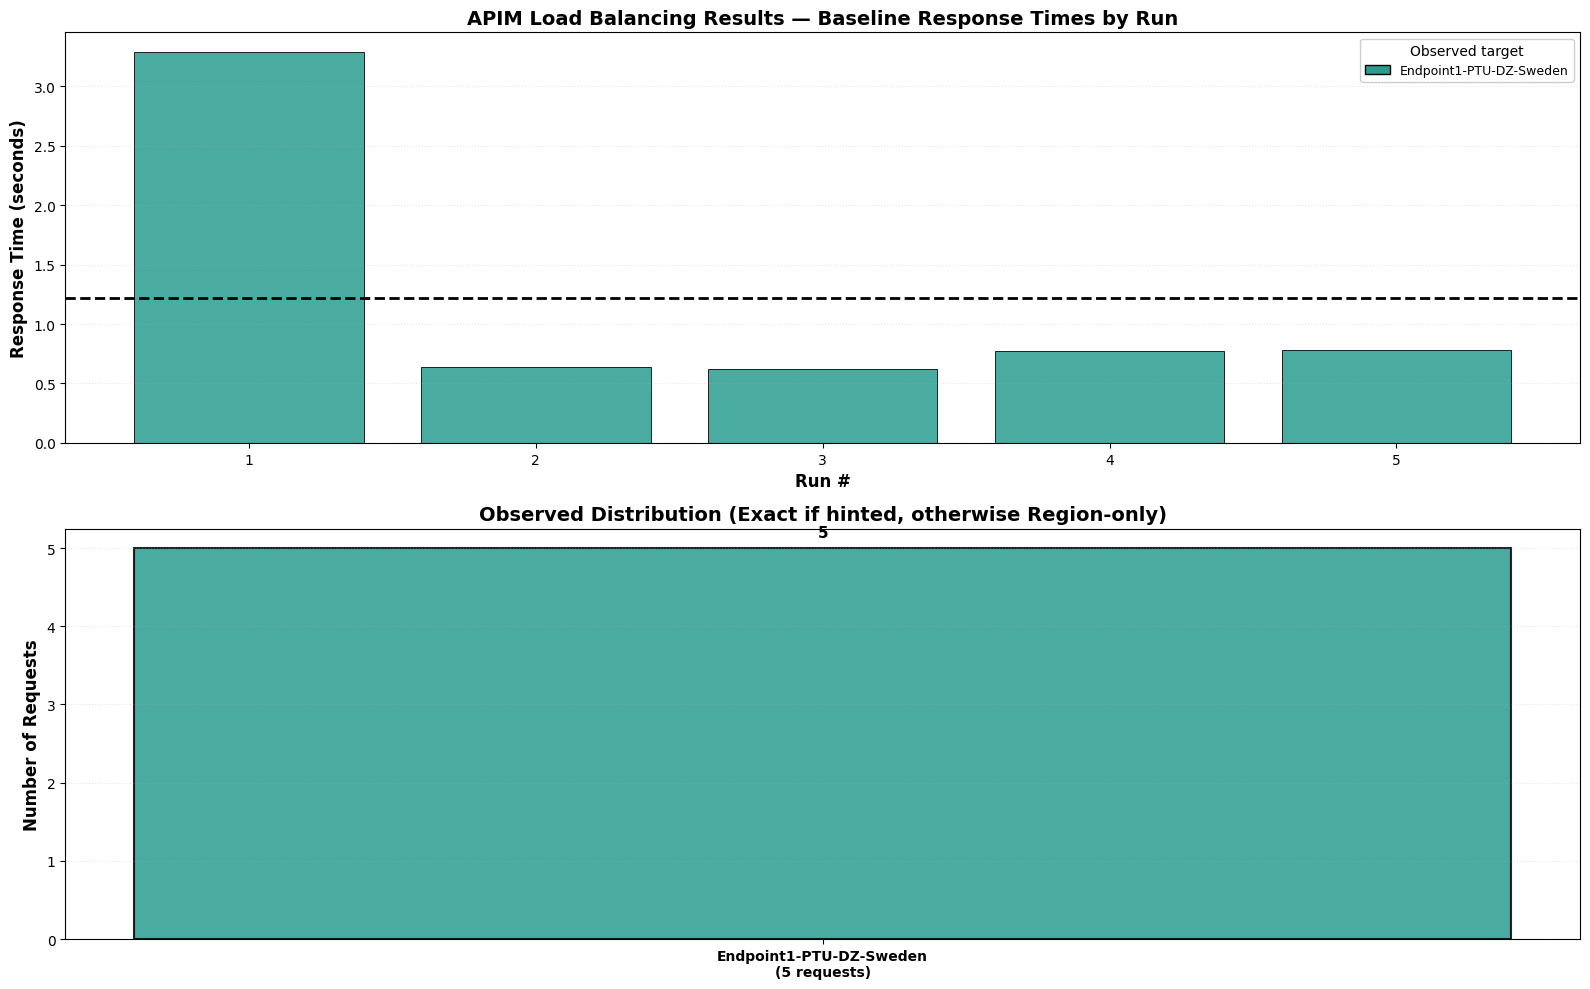


📊 LOAD BALANCING ANALYSIS — BEST AVAILABLE SIGNAL

🎯 Configured Endpoints:
   • Endpoint1-PTU-DZ-Sweden | swedencentral | Priority 1
   • Endpoint3-PayGo-DZ-Germany | germanywestcentral | Priority 2 | Weight 50
   • Endpoint2-PayGo-DZ-Sweden | swedencentral | Priority 2 | Weight 50
   • Endpoint4-PayGo-Global-Germany | germanywestcentral | Priority 3

📈 Observed Distribution:
   • Endpoint1-PTU-DZ-Sweden: 5 requests (100.0%)

⏱️ Response Time Statistics:
   • Average: 1.222s
   • Min: 0.622s
   • Max: 3.290s
   • Median: 0.775s
   • Std Dev: 1.158s

⚠️ Note: APIM did not return backend hint headers for this run.
   The chart is region-only and cannot distinguish multiple backends in the same region.
   Use Step 7b and Step 7c for exact backend attribution from diagnostics.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as pltRectangle
import matplotlib as mpl
import re

api_runs = globals().get('api_runs', [])

if api_runs:
    mpl.rcParams['figure.figsize'] = [16, 9]

    # Support both tuple formats:
    # (response_time, region) and (response_time, region, endpoint_hint)
    parsed_runs = []
    for run in api_runs:
        if len(run) >= 3:
            parsed_runs.append((run[0], run[1], run[2]))
        else:
            parsed_runs.append((run[0], run[1], None))

    df = pd.DataFrame(parsed_runs, columns=['Response Time', 'Region', 'EndpointHint'])
    df['Run'] = range(1, len(df) + 1)

    def normalize_region_name(value):
        txt = str(value).strip().lower()
        txt = re.sub(r'[^a-z0-9]+', '', txt)
        aliases = {
            'swedencentral': 'swedencentral',
            'germanywestcentral': 'germanywestcentral',
        }
        return aliases.get(txt, txt)

    region_label_map = {
        'swedencentral': 'Endpoint1-PTU-DZ-Sweden',
        'germanywestcentral': 'Germany West Central (region-only)',
    }

    endpoint_color_map = {
        'Endpoint1-PTU-DZ-Sweden': '#006400',
        'Endpoint2-PayGo-DZ-Sweden': '#1E90FF',
        'Endpoint3-PayGo-DZ-Germany': '#FFD700',
        'Endpoint4-PayGo-Global-Germany': '#FF0000',
        'Endpoint1-PTU-DZ-Sweden': '#2A9D8F',
        'Germany West Central (region-only)': '#E76F51',
    }
    base_colors = [
        '#2A9D8F', '#1D3557', '#F4A261', '#457B9D',
        '#E76F51', '#8AB17D', '#6D597A', '#E63946'
    ]
    all_endpoints = [ep['name'] for ep in sorted(aiservices_config, key=lambda e: (e.get('priority', 999), e['location'], e['name']))]
    color_idx = 0
    for endpoint_name in all_endpoints:
        if endpoint_name not in endpoint_color_map:
            endpoint_color_map[endpoint_name] = base_colors[color_idx % len(base_colors)]
            color_idx += 1

    def resolve_observed_target(row):
        hint = row['EndpointHint']
        if isinstance(hint, str) and hint.strip():
            return hint.strip()

        region_key = normalize_region_name(row['Region'])
        if region_key in region_label_map:
            return region_label_map[region_key]

        return f"Unknown ({row['Region']})"

    df['ObservedTarget'] = df.apply(resolve_observed_target, axis=1)

    for observed_target in df['ObservedTarget'].unique():
        if observed_target not in endpoint_color_map:
            endpoint_color_map[observed_target] = '#BDBDBD'

    bar_colors = [endpoint_color_map.get(target, '#BDBDBD') for target in df['ObservedTarget']]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.bar(df['Run'], df['Response Time'], color=bar_colors, edgecolor='black', linewidth=0.7, alpha=0.85)

    average = df['Response Time'].mean()
    ax1.axhline(y=average, color='black', linestyle='--', linewidth=2, label=f'Average: {average:.3f}s')

    ax1.set_title('APIM Load Balancing Results — Baseline Response Times by Run', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Run #', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Response Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, len(df) + 1, 2 if len(df) > 15 else 1))
    ax1.grid(axis='y', alpha=0.3, linestyle=':')

    legend_elements = [
        pltRectangle((0, 0), 1, 1, facecolor=endpoint_color_map[name], edgecolor='black', label=name)
        for name in df['ObservedTarget'].drop_duplicates().tolist()
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, title='Observed target')

    target_counts = df['ObservedTarget'].value_counts()
    target_labels = [f"{target}\n({count} requests)" for target, count in target_counts.items()]

    ax2.bar(
        range(len(target_counts)),
        target_counts.values,
        color=[endpoint_color_map.get(target, '#BDBDBD') for target in target_counts.index],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.set_xticks(range(len(target_counts)))
    ax2.set_xticklabels(target_labels, fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Requests', fontsize=12, fontweight='bold')
    ax2.set_title('Observed Distribution (Exact if hinted, otherwise Region-only)', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle=':')

    for i, value in enumerate(target_counts.values):
        ax2.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("📊 LOAD BALANCING ANALYSIS — BEST AVAILABLE SIGNAL")
    print("=" * 70)

    print("\n🎯 Configured Endpoints:")
    for ep in sorted(aiservices_config, key=lambda e: (e.get('priority', 999), e['location'], e['name'])):
        details = f"   • {ep['name']} | {ep['location']} | Priority {ep['priority']}"
        if 'weight' in ep:
            details += f" | Weight {ep['weight']}"
        print(details)

    print("\n📈 Observed Distribution:")
    for target, count in target_counts.items():
        percentage = (count / len(df)) * 100
        print(f"   • {target}: {count} requests ({percentage:.1f}%)")

    print("\n⏱️ Response Time Statistics:")
    print(f"   • Average: {average:.3f}s")
    print(f"   • Min: {df['Response Time'].min():.3f}s")
    print(f"   • Max: {df['Response Time'].max():.3f}s")
    print(f"   • Median: {df['Response Time'].median():.3f}s")
    print(f"   • Std Dev: {df['Response Time'].std():.3f}s")

    if df['EndpointHint'].isna().all() or (df['EndpointHint'].astype(str).str.strip() == '').all():
        print("\n⚠️ Note: APIM did not return backend hint headers for this run.")
        print("   The chart is region-only and cannot distinguish multiple backends in the same region.")
        print("   Use Step 7b and Step 7c for exact backend attribution from diagnostics.")

    print("=" * 70)
else:
    print("No test data available. Run Step 7 first, or rerun it after a kernel restart.")


---

## Step 7b: Query Exact Backend Attribution from APIM Traces

Use APIM managed gateway traces to retrieve the exact backend selected for the Step 7 requests.

- This is the authoritative source for exact backend attribution in this notebook
- Step 7 captures an `Apim-Trace-Id` for each request when trace credentials are available
- This step resolves the selected backend from the APIM trace payload itself
- Application Insights can still be useful for request-level diagnostics, but in this scenario it may remain region-only rather than endpoint-exact
- If trace capture was unavailable, rerun Step 7 and then rerun this cell

Run this after Step 7. Unlike Application Insights, this path does not depend on ingestion delay.

In [11]:
import json
import pandas as pd
import re
import subprocess
from urllib.parse import urlparse

backend_diagnostics_df = pd.DataFrame()
api_run_diagnostics = globals().get('api_run_diagnostics', [])

if not api_run_diagnostics:
    print('No Step 7 request metadata available. Run Step 7 first.')
elif not apim_service_id:
    print('APIM service ID is unavailable. Re-run Step 6 first.')
elif not backend_host_to_name:
    print('Backend host mapping is empty. Re-run Step 6 to refresh deployment outputs.')
else:
    normalized_backend_host_to_name = {}
    for host_key, backend_name in backend_host_to_name.items():
        key = str(host_key).strip().lower()
        if not key:
            continue
        normalized_backend_host_to_name[key.split(':')[0]] = backend_name

    tracked_backend_hosts = sorted(normalized_backend_host_to_name.keys())
    tracked_backend_names = sorted({str(name).strip() for name in normalized_backend_host_to_name.values() if str(name).strip()})

    def fetch_trace_payload(trace_id):
        if not trace_id:
            return None
        result = subprocess.run(
            [
                'az', 'rest',
                '--method', 'post',
                '--uri', f'{apim_service_id}/gateways/managed/listTrace?api-version=2023-05-01-preview',
                '--body', json.dumps({'traceId': trace_id}),
                '-o', 'json',
            ],
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            return None
        try:
            return json.loads(result.stdout or '{}')
        except json.JSONDecodeError:
            return None

    def resolve_backend_host_from_trace(trace_payload):
        if not trace_payload:
            return ''

        trace_text = json.dumps(trace_payload).lower()
        for tracked_host in tracked_backend_hosts:
            if tracked_host in trace_text:
                return tracked_host

        url_match = re.search(r'https://([a-z0-9.-]+)', trace_text)
        if url_match:
            candidate_host = url_match.group(1).split(':')[0]
            if candidate_host in normalized_backend_host_to_name:
                return candidate_host

        return ''

    def resolve_backend_name_from_trace(trace_payload):
        if not trace_payload:
            return 'Unknown backend'

        backend_host = resolve_backend_host_from_trace(trace_payload)
        if backend_host:
            return normalized_backend_host_to_name.get(backend_host, 'Unknown backend')

        trace_text = json.dumps(trace_payload).lower()
        for backend_name in tracked_backend_names:
            if backend_name.lower() in trace_text:
                return backend_name

        return 'Unknown backend'

    trace_rows = []
    traced_requests = [run for run in api_run_diagnostics if run.get('traceId')]

    for run in traced_requests:
        trace_payload = fetch_trace_payload(run.get('traceId'))
        backend_host = resolve_backend_host_from_trace(trace_payload)
        backend_display_name = resolve_backend_name_from_trace(trace_payload)

        trace_rows.append({
            'requestNumber': run.get('requestNumber'),
            'requestTimestamp': run.get('requestTimestamp'),
            'backendDisplayName': backend_display_name,
            'backendHost': backend_host,
            'requestResultCode': run.get('requestResultCode', ''),
            'backendResultCode': '',
            'requestDurationSeconds': run.get('requestDurationSeconds'),
            'backendDurationSeconds': pd.NA,
            'requestUrl': run.get('requestUrl', ''),
            'clientObservedRegion': run.get('region', 'Unknown'),
            'traceId': run.get('traceId', ''),
        })

    if not trace_rows:
        print('No APIM trace IDs were captured in Step 7.')
        print('Re-run Step 7, then rerun this cell.')
    else:
        backend_diagnostics_df = pd.DataFrame(trace_rows)
        backend_diagnostics_df = backend_diagnostics_df.sort_values('requestNumber').reset_index(drop=True)

        print(f"Retrieved {len(backend_diagnostics_df)} exact APIM trace rows from Step 7.")
        display_columns = [
            'requestNumber',
            'requestTimestamp',
            'backendDisplayName',
            'backendHost',
            'clientObservedRegion',
            'requestResultCode',
            'requestDurationSeconds',
            'traceId',
        ]
        display(backend_diagnostics_df[display_columns])

        unresolved_count = (backend_diagnostics_df['backendDisplayName'] == 'Unknown backend').sum()
        exact_count = len(backend_diagnostics_df) - unresolved_count
        print(f"\n✅ Exact APIM trace attribution rows: {exact_count}/{len(backend_diagnostics_df)}")
        if unresolved_count > 0:
            print(f"⚠️ Unresolved trace rows: {unresolved_count}/{len(backend_diagnostics_df)}")

Retrieved 5 exact APIM trace rows from Step 7.


,requestNumber,requestTimestamp,backendDisplayName,backendHost,clientObservedRegion,requestResultCode,requestDurationSeconds,traceId
0,1,2026-04-09T20:24:52.945556Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,3.289500,b2ca133fd2d6488ba6c6f9aa0451c8e7
1,2,2026-04-09T20:24:56.336129Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.640770,2dff578f6bea4d0eb27bc1246fe9ef3a
2,3,2026-04-09T20:24:57.077560Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.621652,5c78ae6578594197b26a1bd42e8f21ee
3,4,2026-04-09T20:24:57.799644Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.775448,06b3bfab66ad44279eafb0e864cd7b68
4,5,2026-04-09T20:24:58.675577Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.781565,4bf355f90c8540b884b6e74997e82278



✅ Exact APIM trace attribution rows: 5/5


---

## Step 7c: Visualize Exact Backend Attribution

Visualize the exact backend assignments returned by APIM traces.

- Uses the backend resolved from APIM managed gateway trace payloads
- Shows exact backend distribution without relying on region-only inference
- Helps validate which backend actually handled each Step 7 request

Run this after Step 7b completes.

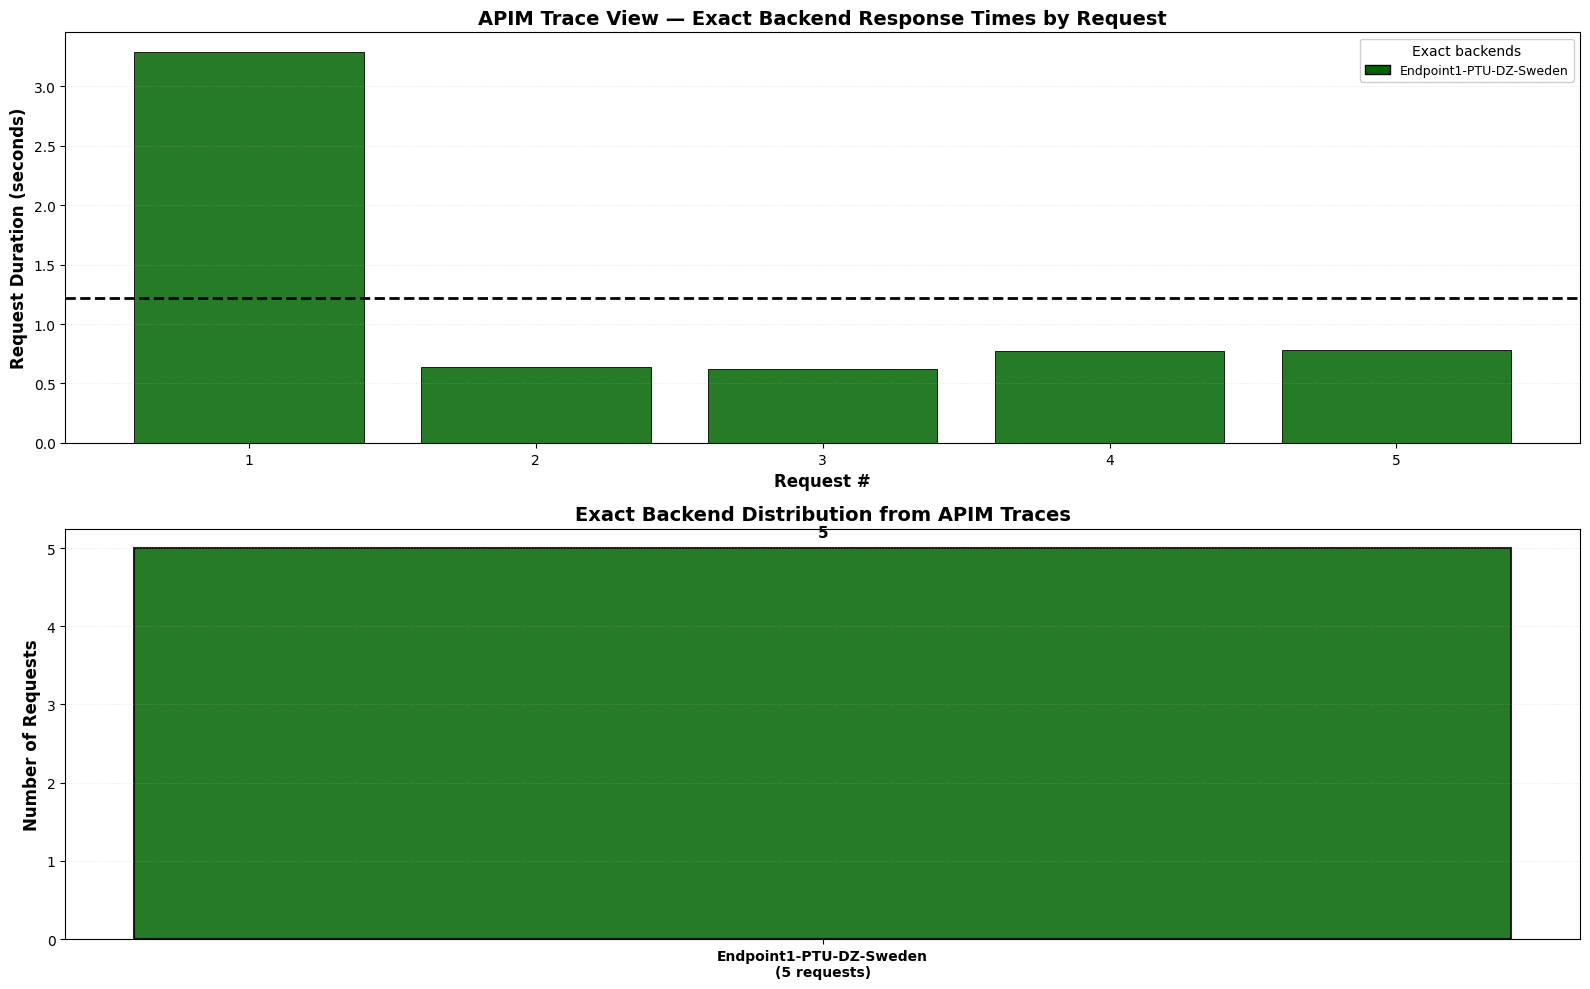


📊 EXACT BACKEND ATTRIBUTION FROM APIM TRACES
   • Endpoint1-PTU-DZ-Sweden: 5 requests (100.0%)


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as pltRectangle

backend_diagnostics_df = globals().get('backend_diagnostics_df', pd.DataFrame())

if not backend_diagnostics_df.empty:
    mpl.rcParams['figure.figsize'] = [16, 9]

    diagnostics_plot_df = backend_diagnostics_df.copy().reset_index(drop=True)
    diagnostics_plot_df['Run'] = range(1, len(diagnostics_plot_df) + 1)

    fallback_index = 0
    for backend_name in diagnostics_plot_df['backendDisplayName'].drop_duplicates().tolist():
        if backend_name not in backend_color_map:
            backend_color_map[backend_name] = fallback_colors[fallback_index % len(fallback_colors)]
            fallback_index += 1

    bar_colors = [backend_color_map.get(name, '#BDBDBD') for name in diagnostics_plot_df['backendDisplayName']]
    backend_counts = diagnostics_plot_df['backendDisplayName'].value_counts()
    average_request_duration = diagnostics_plot_df['requestDurationSeconds'].dropna().mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.bar(
        diagnostics_plot_df['Run'],
        diagnostics_plot_df['requestDurationSeconds'],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85,
    )

    if pd.notna(average_request_duration):
        ax1.axhline(
            y=average_request_duration,
            color='black',
            linestyle='--',
            linewidth=2,
            label=f'Average: {average_request_duration:.3f}s',
        )

    ax1.set_title('APIM Trace View — Exact Backend Response Times by Request', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Request #', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Request Duration (seconds)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, len(diagnostics_plot_df) + 1, 2 if len(diagnostics_plot_df) > 15 else 1))
    ax1.grid(axis='y', alpha=0.3, linestyle=':')

    legend_elements = [
        pltRectangle((0, 0), 1, 1, facecolor=backend_color_map[name], edgecolor='black', label=name)
        for name in diagnostics_plot_df['backendDisplayName'].drop_duplicates().tolist()
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, title='Exact backends')

    ax2.bar(
        range(len(backend_counts)),
        backend_counts.values,
        color=[backend_color_map.get(name, '#BDBDBD') for name in backend_counts.index],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.set_xticks(range(len(backend_counts)))
    ax2.set_xticklabels([f"{name}\n({count} requests)" for name, count in backend_counts.items()], fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Requests', fontsize=12, fontweight='bold')
    ax2.set_title('Exact Backend Distribution from APIM Traces', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle=':')

    for i, value in enumerate(backend_counts.values):
        ax2.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print('📊 EXACT BACKEND ATTRIBUTION FROM APIM TRACES')
    print("=" * 70)
    for backend_name, count in backend_counts.items():
        percentage = (count / len(diagnostics_plot_df)) * 100
        print(f"   • {backend_name}: {count} requests ({percentage:.1f}%)")
    print("=" * 70)
else:
    print('No exact trace data available. Run Step 7b first.')

---

## Step 8: Extended Sequential Test (20 Requests)

Run an extended sequential test with 20 requests to observe routing behavior over a longer sample. This variant:

- Runs **20 requests** instead of 5 for a larger sample window
- Continues capturing `x-ms-region` for client-visible region analysis
- Attempts to capture an endpoint/backend hint header so Step 8a can use endpoint-style labels when APIM exposes them
- Also captures `Apim-Trace-Id` values so Step 8b can resolve the exact backend from APIM traces
- Stores the extended request metadata needed for regional, hint-based, and exact-backend analysis
- Is useful for validating whether traffic begins to spread beyond the Priority 1 backend under sustained demand

Compare the outputs of Step 8a and Step 8b/9c to see the difference between best-available client-visible signals and authoritative exact backend attribution.

In [13]:
import datetime
import json
import requests
import subprocess
import time

runs = 20
sleep_time_ms = 100
url = f"{apim_resource_gateway_url}/{inference_api_path}/openai/deployments/{models_config[0]['name']}/chat/completions?api-version={inference_api_version}"
messages = {"messages": [
    {"role": "system", "content": "You are a sarcastic, unhelpful assistant."},
    {"role": "user", "content": "Can you tell me the time, please?"}
]}

api_runs_extended = []
api_run_diagnostics_extended = []


trace_token = ''
if apim_service_id:
    debug_credentials_request = {
        'credentialsExpireAfter': 'PT1H',
        'apiId': f'{apim_service_id}/apis/inference-api',
        'purposes': ['tracing'],
    }
    debug_credentials_result = subprocess.run(
        [
            'az', 'rest',
            '--method', 'post',
            '--uri', f'{apim_service_id}/gateways/managed/listDebugCredentials?api-version=2023-05-01-preview',
            '--body', json.dumps(debug_credentials_request),
            '-o', 'json',
        ],
        capture_output=True,
        text=True,
    )
    if debug_credentials_result.returncode == 0:
        trace_token = (json.loads(debug_credentials_result.stdout or '{}').get('token') or '').strip()

if trace_token:
    print('APIM trace capture: enabled')
else:
    print('APIM trace capture: unavailable, Step 8b will not have exact APIM trace data')

# Initialize session for connection pooling
session = requests.Session()
session.headers.update({'api-key': api_key})
if trace_token:
    session.headers.update({'Apim-Debug-Authorization': trace_token})

try:
    for i in range(runs):
        print(f"▶️ Run {i+1}/{runs}:")

        request_timestamp = datetime.datetime.now(datetime.UTC).isoformat().replace('+00:00', 'Z')
        start_time = time.time()
        response = session.post(url, json=messages)
        response_time = time.time() - start_time
        print(f"⌚ {response_time:.2f} seconds")

        utils.print_response_code(response)

        trace_id = response.headers.get('Apim-Trace-Id', '')
        region = response.headers.get('x-ms-region', 'Unknown')
        print(f"x-ms-region: \x1b[1;32m{region}\x1b[0m")

        endpoint_hint = None
        for header_name in endpoint_hint_headers:
            header_value = response.headers.get(header_name)
            if header_value:
                endpoint_hint = header_value
                break

        if endpoint_hint:
            print(f"endpoint-hint: \x1b[1;36m{endpoint_hint}\x1b[0m")
        elif i == 0:
            print('endpoint-hint: not present in response headers')

        api_runs_extended.append((response_time, region, endpoint_hint))
        api_run_diagnostics_extended.append({
            'requestNumber': i + 1,
            'requestTimestamp': request_timestamp,
            'requestResultCode': str(response.status_code),
            'requestDurationSeconds': response_time,
            'region': region,
            'endpointHint': endpoint_hint or '',
            'traceId': trace_id,
            'requestUrl': url,
        })

        if response.status_code == 200:
            data = json.loads(response.text)
            print(f"Token usage: {json.dumps(dict(data.get('usage')), indent=2)}\n")
            print(f"💬 {data.get('choices')[0].get('message').get('content')}\n")
        else:
            print(f"Error: {response.text}\n")

        time.sleep(sleep_time_ms / 1000)
finally:
    session.close()

trace_count_extended = sum(1 for run in api_run_diagnostics_extended if run.get('traceId'))
exact_hint_count_extended = sum(1 for _, _, hint in api_runs_extended if hint)
print(f"\n✅ Extended sequential test complete! ({len(api_runs_extended)} requests captured)")
print(f"   Exact endpoint hints captured: {exact_hint_count_extended}/{len(api_runs_extended)}")
print(f"   APIM trace IDs captured: {trace_count_extended}/{len(api_run_diagnostics_extended)}")

APIM trace capture: enabled
▶️ Run 1/20:
⌚ 1.08 seconds
Response status: 200 - OK
x-ms-region: Sweden Central
endpoint-hint: not present in response headers
Token usage: {
  "completion_tokens": 54,
  "completion_tokens_details": {
    "accepted_prediction_tokens": 0,
    "audio_tokens": 0,
    "reasoning_tokens": 0,
    "rejected_prediction_tokens": 0
  },
  "prompt_tokens": 31,
  "prompt_tokens_details": {
    "audio_tokens": 0,
    "cached_tokens": 0
  },
  "total_tokens": 85
}

💬 Oh, absolutely! Just give me a moment to check my imaginary clock. Spoiler: I don’t have a clue what time it is. Maybe you should look at a clock… or your phone. You know, the things everyone carries around all the time?

▶️ Run 2/20:
⌚ 0.67 seconds
Response status: 200 - OK
x-ms-region: Sweden Central
Token usage: {
  "completion_tokens": 37,
  "completion_tokens_details": {
    "accepted_prediction_tokens": 0,
    "audio_tokens": 0,
    "reasoning_tokens": 0,
    "rejected_prediction_tokens": 0
  },
  "p

---

## Step 8a: Visualize Extended Test Results

Visualize the 20-request sequential test from Step 8 using the best available client-visible signal.

- Prefers exact endpoint/backend names when Step 8 captured a hint header
- Otherwise falls back to region-only buckets instead of guessing a specific backend
- Complements Step 8b and Step 8c, which remain the authoritative exact-attribution view from APIM traces

Run this after Step 8 completes.

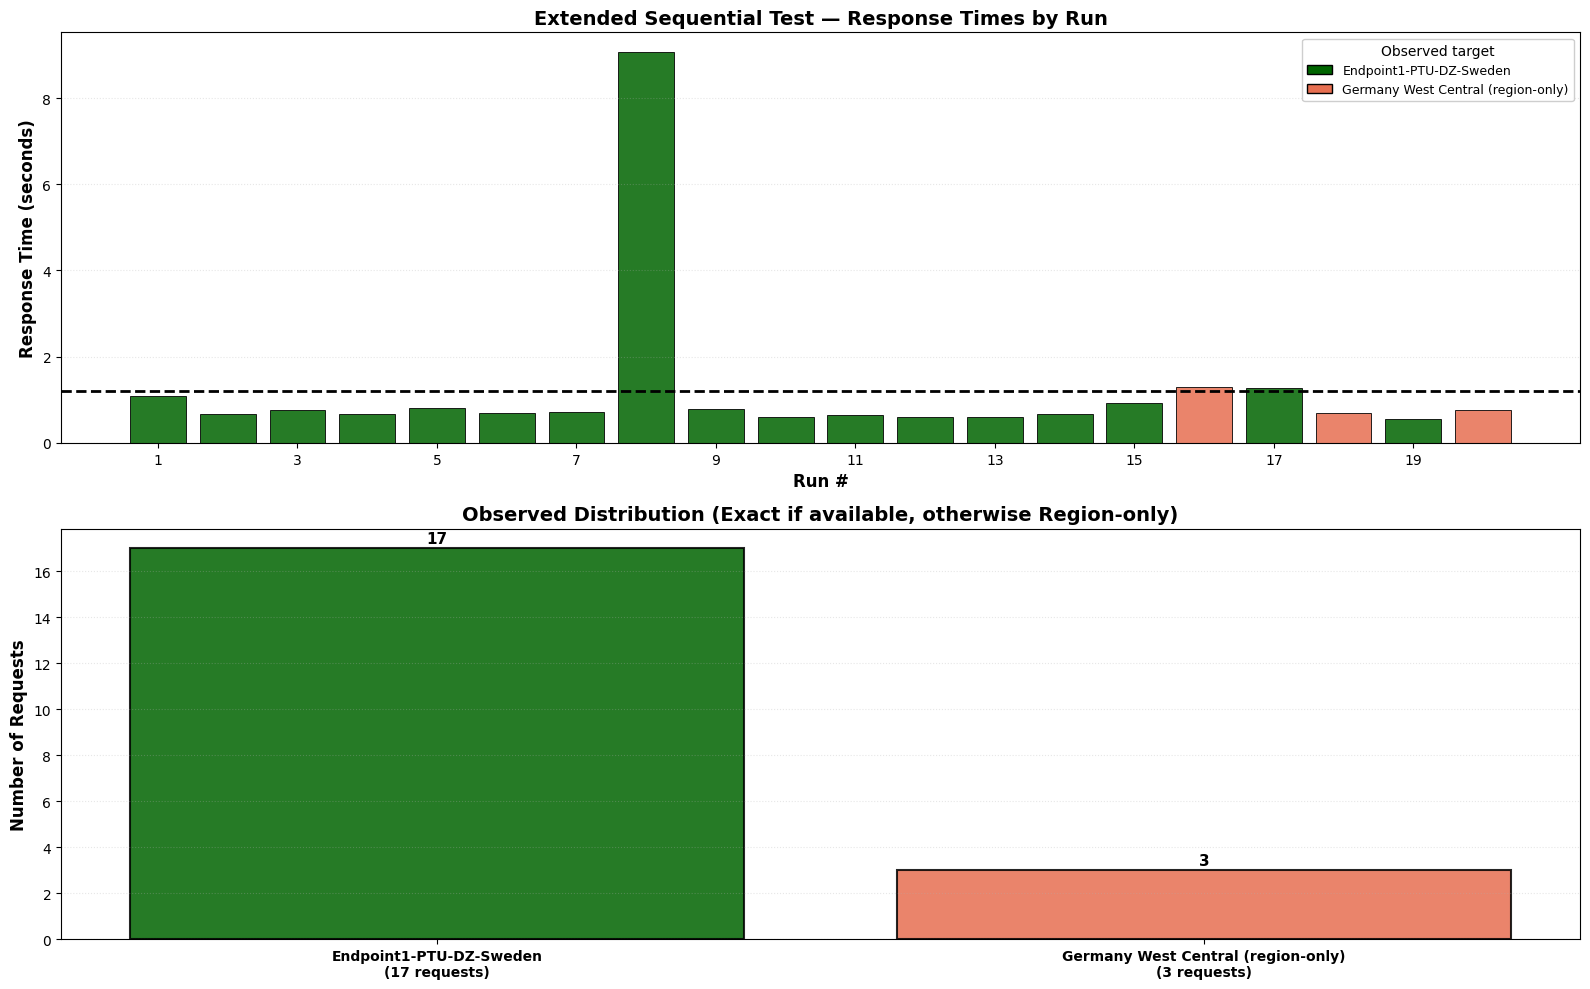


📊 EXTENDED TEST ANALYSIS — BEST AVAILABLE SIGNAL

🎯 Configured Endpoints:
   • Endpoint1-PTU-DZ-Sweden | swedencentral | Priority 1
   • Endpoint3-PayGo-DZ-Germany | germanywestcentral | Priority 2 | Weight 50
   • Endpoint2-PayGo-DZ-Sweden | swedencentral | Priority 2 | Weight 50
   • Endpoint4-PayGo-Global-Germany | germanywestcentral | Priority 3

📈 Observed Distribution:
   • Endpoint1-PTU-DZ-Sweden: 17 requests (85.0%)
   • Germany West Central (region-only): 3 requests (15.0%)

⏱️ Response Time Statistics:
   • Average: 1.193s
   • Min: 0.555s
   • Max: 9.071s
   • Median: 0.709s
   • Std Dev: 1.866s

⚠️ Note: APIM did not return backend hint headers for this run.
   The chart is still region-aware and may not distinguish multiple backends in the same region.
   Use Step 8b and Step 8c for authoritative exact backend attribution from APIM traces.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as pltRectangle
import re

api_runs_extended = globals().get('api_runs_extended', [])
backend_diagnostics_df_extended = globals().get('backend_diagnostics_df_extended', pd.DataFrame())

if api_runs_extended:
    mpl.rcParams['figure.figsize'] = [16, 9]

    parsed_runs_extended = []
    for run in api_runs_extended:
        if len(run) >= 3:
            parsed_runs_extended.append((run[0], run[1], run[2]))
        else:
            parsed_runs_extended.append((run[0], run[1], None))

    df_extended = pd.DataFrame(parsed_runs_extended, columns=['Response Time', 'Region', 'EndpointHint'])
    df_extended['Run'] = range(1, len(df_extended) + 1)

    def normalize_region_name(value):
        txt = str(value).strip().lower()
        txt = re.sub(r'[^a-z0-9]+', '', txt)
        aliases = {
            'swedencentral': 'swedencentral',
            'germanywestcentral': 'germanywestcentral',
        }
        return aliases.get(txt, txt)

    region_label_map = {
        'swedencentral': 'Endpoint1-PTU-DZ-Sweden',
        'germanywestcentral': 'Germany West Central (region-only)',
    }

    endpoint_color_map = {
        'Endpoint1-PTU-DZ-Sweden': '#006400',
        'Endpoint2-PayGo-DZ-Sweden': '#1E90FF',
        'Endpoint3-PayGo-DZ-Germany': '#FFD700',
        'Endpoint4-PayGo-Global-Germany': '#FF0000',
        'Germany West Central (region-only)': '#E76F51',
        'Unknown backend': '#BDBDBD',
    }

    fallback_colors = ['#2A9D8F', '#457B9D', '#F4A261', '#8AB17D', '#6D597A']
    fallback_index = 0
    for endpoint_name in [ep['name'] for ep in sorted(aiservices_config, key=lambda e: (e.get('priority', 999), e['location'], e['name']))]:
        if endpoint_name not in endpoint_color_map:
            endpoint_color_map[endpoint_name] = fallback_colors[fallback_index % len(fallback_colors)]
            fallback_index += 1

    trace_name_by_request = {}
    if not backend_diagnostics_df_extended.empty and {'requestNumber', 'backendDisplayName'}.issubset(backend_diagnostics_df_extended.columns):
        trace_name_by_request = {
            int(row['requestNumber']): row['backendDisplayName']
            for _, row in backend_diagnostics_df_extended.iterrows()
            if pd.notna(row.get('requestNumber')) and str(row.get('backendDisplayName', '')).strip()
        }

    def resolve_observed_target(row):
        request_number = int(row['Run'])

        trace_backend_name = trace_name_by_request.get(request_number, '')
        if trace_backend_name and trace_backend_name != 'Unknown backend':
            return trace_backend_name

        hint = row['EndpointHint']
        if isinstance(hint, str) and hint.strip():
            return hint.strip()

        region_key = normalize_region_name(row['Region'])
        if region_key in region_label_map:
            return region_label_map[region_key]

        return f"Unknown ({row['Region']})"

    df_extended['ObservedTarget'] = df_extended.apply(resolve_observed_target, axis=1)

    for observed_target in df_extended['ObservedTarget'].unique():
        if observed_target not in endpoint_color_map:
            endpoint_color_map[observed_target] = '#BDBDBD'

    bar_colors = [endpoint_color_map.get(target, '#BDBDBD') for target in df_extended['ObservedTarget']]
    target_counts = df_extended['ObservedTarget'].value_counts()
    average = df_extended['Response Time'].mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.bar(df_extended['Run'], df_extended['Response Time'], color=bar_colors, edgecolor='black', linewidth=0.7, alpha=0.85)
    ax1.axhline(y=average, color='black', linestyle='--', linewidth=2, label=f'Average: {average:.3f}s')
    ax1.set_title('Extended Sequential Test — Response Times by Run', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Run #', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Response Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, len(df_extended) + 1, 2 if len(df_extended) > 15 else 1))
    ax1.grid(axis='y', alpha=0.3, linestyle=':')

    legend_elements = [
        pltRectangle((0, 0), 1, 1, facecolor=endpoint_color_map[name], edgecolor='black', label=name)
        for name in df_extended['ObservedTarget'].drop_duplicates().tolist()
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, title='Observed target')

    ax2.bar(
        range(len(target_counts)),
        target_counts.values,
        color=[endpoint_color_map.get(target, '#BDBDBD') for target in target_counts.index],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.set_xticks(range(len(target_counts)))
    ax2.set_xticklabels([f"{target}\n({count} requests)" for target, count in target_counts.items()], fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Requests', fontsize=12, fontweight='bold')
    ax2.set_title('Observed Distribution (Exact if available, otherwise Region-only)', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle=':')

    for i, value in enumerate(target_counts.values):
        ax2.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("📊 EXTENDED TEST ANALYSIS — BEST AVAILABLE SIGNAL")
    print("=" * 70)
    print("\n🎯 Configured Endpoints:")
    for ep in sorted(aiservices_config, key=lambda e: (e.get('priority', 999), e['location'], e['name'])):
        details = f"   • {ep['name']} | {ep['location']} | Priority {ep['priority']}"
        if 'weight' in ep:
            details += f" | Weight {ep['weight']}"
        print(details)

    print("\n📈 Observed Distribution:")
    for target, count in target_counts.items():
        percentage = (count / len(df_extended)) * 100
        print(f"   • {target}: {count} requests ({percentage:.1f}%)")

    print("\n⏱️ Response Time Statistics:")
    print(f"   • Average: {average:.3f}s")
    print(f"   • Min: {df_extended['Response Time'].min():.3f}s")
    print(f"   • Max: {df_extended['Response Time'].max():.3f}s")
    print(f"   • Median: {df_extended['Response Time'].median():.3f}s")
    print(f"   • Std Dev: {df_extended['Response Time'].std():.3f}s")

    if trace_name_by_request:
        print("\n✅ Exact backend names were applied from Step 8b trace results where available.")
    elif df_extended['EndpointHint'].isna().all() or (df_extended['EndpointHint'].astype(str).str.strip() == '').all():
        print("\n⚠️ Note: APIM did not return backend hint headers for this run.")
        print("   The chart is still region-aware and may not distinguish multiple backends in the same region.")
        print("   Use Step 8b and Step 8c for authoritative exact backend attribution from APIM traces.")

    print("=" * 70)
else:
    print('No extended test data available. Run Step 8 first, or rerun it after a kernel restart.')

---

## Step 8b: Query Exact Backend Attribution from APIM Traces (Extended Test)

Use APIM managed gateway traces to retrieve the exact backend used for the extended test traffic.

- This mirrors Step 7b but is scoped for the 20-request run
- Step 8 captures an `Apim-Trace-Id` for each request when trace credentials are available
- This step resolves the selected backend directly from the APIM trace payload
- If trace capture was unavailable, rerun Step 8 and then rerun this cell

Run this after Step 8. This path does not depend on Application Insights ingestion.

In [15]:
import json
import pandas as pd
import re
import subprocess
from urllib.parse import urlparse

backend_diagnostics_df_extended = pd.DataFrame()
api_run_diagnostics_extended = globals().get('api_run_diagnostics_extended', [])

if not api_run_diagnostics_extended:
    print('No Step 8 request metadata available. Run Step 8 first.')
elif not apim_service_id:
    print('APIM service ID is unavailable. Re-run Step 6 first.')
elif not backend_host_to_name:
    print('Backend host mapping is empty. Re-run Step 6 to refresh deployment outputs.')
else:
    normalized_backend_host_to_name = {}
    for host_key, backend_name in backend_host_to_name.items():
        key = str(host_key).strip().lower()
        if not key:
            continue
        normalized_backend_host_to_name[key.split(':')[0]] = backend_name

    tracked_backend_hosts = sorted(normalized_backend_host_to_name.keys())
    tracked_backend_names = sorted({str(name).strip() for name in normalized_backend_host_to_name.values() if str(name).strip()})

    def fetch_trace_payload(trace_id):
        if not trace_id:
            return None
        result = subprocess.run(
            [
                'az', 'rest',
                '--method', 'post',
                '--uri', f'{apim_service_id}/gateways/managed/listTrace?api-version=2023-05-01-preview',
                '--body', json.dumps({'traceId': trace_id}),
                '-o', 'json',
            ],
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            return None
        try:
            return json.loads(result.stdout or '{}')
        except json.JSONDecodeError:
            return None

    def resolve_backend_host_from_trace(trace_payload):
        if not trace_payload:
            return ''

        trace_text = json.dumps(trace_payload).lower()
        for tracked_host in tracked_backend_hosts:
            if tracked_host in trace_text:
                return tracked_host

        url_match = re.search(r'https://([a-z0-9.-]+)', trace_text)
        if url_match:
            candidate_host = url_match.group(1).split(':')[0]
            if candidate_host in normalized_backend_host_to_name:
                return candidate_host

        return ''

    def resolve_backend_name_from_trace(trace_payload):
        if not trace_payload:
            return 'Unknown backend'

        backend_host = resolve_backend_host_from_trace(trace_payload)
        if backend_host:
            return normalized_backend_host_to_name.get(backend_host, 'Unknown backend')

        trace_text = json.dumps(trace_payload).lower()
        for backend_name in tracked_backend_names:
            if backend_name.lower() in trace_text:
                return backend_name

        return 'Unknown backend'

    trace_rows = []
    traced_requests = [run for run in api_run_diagnostics_extended if run.get('traceId')]

    for run in traced_requests:
        trace_payload = fetch_trace_payload(run.get('traceId'))
        backend_host = resolve_backend_host_from_trace(trace_payload)
        backend_display_name = resolve_backend_name_from_trace(trace_payload)

        trace_rows.append({
            'requestNumber': run.get('requestNumber'),
            'requestTimestamp': run.get('requestTimestamp'),
            'backendDisplayName': backend_display_name,
            'backendHost': backend_host,
            'requestResultCode': run.get('requestResultCode', ''),
            'backendResultCode': '',
            'requestDurationSeconds': run.get('requestDurationSeconds'),
            'backendDurationSeconds': pd.NA,
            'requestUrl': run.get('requestUrl', ''),
            'clientObservedRegion': run.get('region', 'Unknown'),
            'traceId': run.get('traceId', ''),
        })

    if not trace_rows:
        print('No APIM trace IDs were captured in Step 8.')
        print('Re-run Step 9, then rerun this cell.')
    else:
        backend_diagnostics_df_extended = pd.DataFrame(trace_rows)
        backend_diagnostics_df_extended = backend_diagnostics_df_extended.sort_values('requestNumber').reset_index(drop=True)

        print(f"Retrieved {len(backend_diagnostics_df_extended)} exact APIM trace rows from Step 8.")
        display_columns = [
            'requestNumber',
            'requestTimestamp',
            'backendDisplayName',
            'backendHost',
            'clientObservedRegion',
            'requestResultCode',
            'requestDurationSeconds',
            'traceId',
        ]
        display(backend_diagnostics_df_extended[display_columns])

        unresolved_count = (backend_diagnostics_df_extended['backendDisplayName'] == 'Unknown backend').sum()
        exact_count = len(backend_diagnostics_df_extended) - unresolved_count
        print(f"\n✅ Exact APIM trace attribution rows: {exact_count}/{len(backend_diagnostics_df_extended)}")
        if unresolved_count > 0:
            print(f"⚠️ Unresolved trace rows: {unresolved_count}/{len(backend_diagnostics_df_extended)}")

Retrieved 20 exact APIM trace rows from Step 8.


,requestNumber,requestTimestamp,backendDisplayName,backendHost,clientObservedRegion,requestResultCode,requestDurationSeconds,traceId
0,1,2026-04-09T20:29:00.241214Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,1.079737,9a73c3d862d248c7b2d2fb84095ca2e4
1,2,2026-04-09T20:29:01.421999Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.668671,8cab6e4e068a4c8c82cef950da532f1f
2,3,2026-04-09T20:29:02.191330Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.767130,fd23ab6f5e744f2c8f4e7ec376f9bd96
3,4,2026-04-09T20:29:03.058893Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.663555,7d42e0595b1b4837888eb3045023e3c7
4,5,2026-04-09T20:29:03.822897Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.812751,9f21b36cf0a448fdb82045e4f1e25df6
5,6,2026-04-09T20:29:04.736109Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.683038,cf5f5a77391143298cfec33505c2d569
6,7,2026-04-09T20:29:05.519615Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.726385,f6145c2f4d124f07801b3a6b2af627ed
7,8,2026-04-09T20:29:06.346661Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,9.071216,28cb3b0f5af7429b95719a8dff8ea5d7
8,9,2026-04-09T20:29:15.518363Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.779095,5cc2b779b582491e9ed98b6b3dc23845
9,10,2026-04-09T20:29:16.397986Z,Endpoint1-PTU-DZ-Sweden,endpoint1-ptu-dz-sweden-nxghguyrkhpc2.cognitiv...,Sweden Central,200,0.609518,b90dd23d77e74978b85a23a1cb9bc507



✅ Exact APIM trace attribution rows: 20/20


---

## Step 8c: Visualize Exact Backend Attribution (Extended Test)

Visualize the exact backend assignments returned by APIM traces for the extended test.

- Uses the backend resolved from APIM managed gateway trace payloads
- Mirrors Step 7c but for the extended 20-request run
- Helps validate actual backend spread during higher request volume

Run this after Step 8b completes.

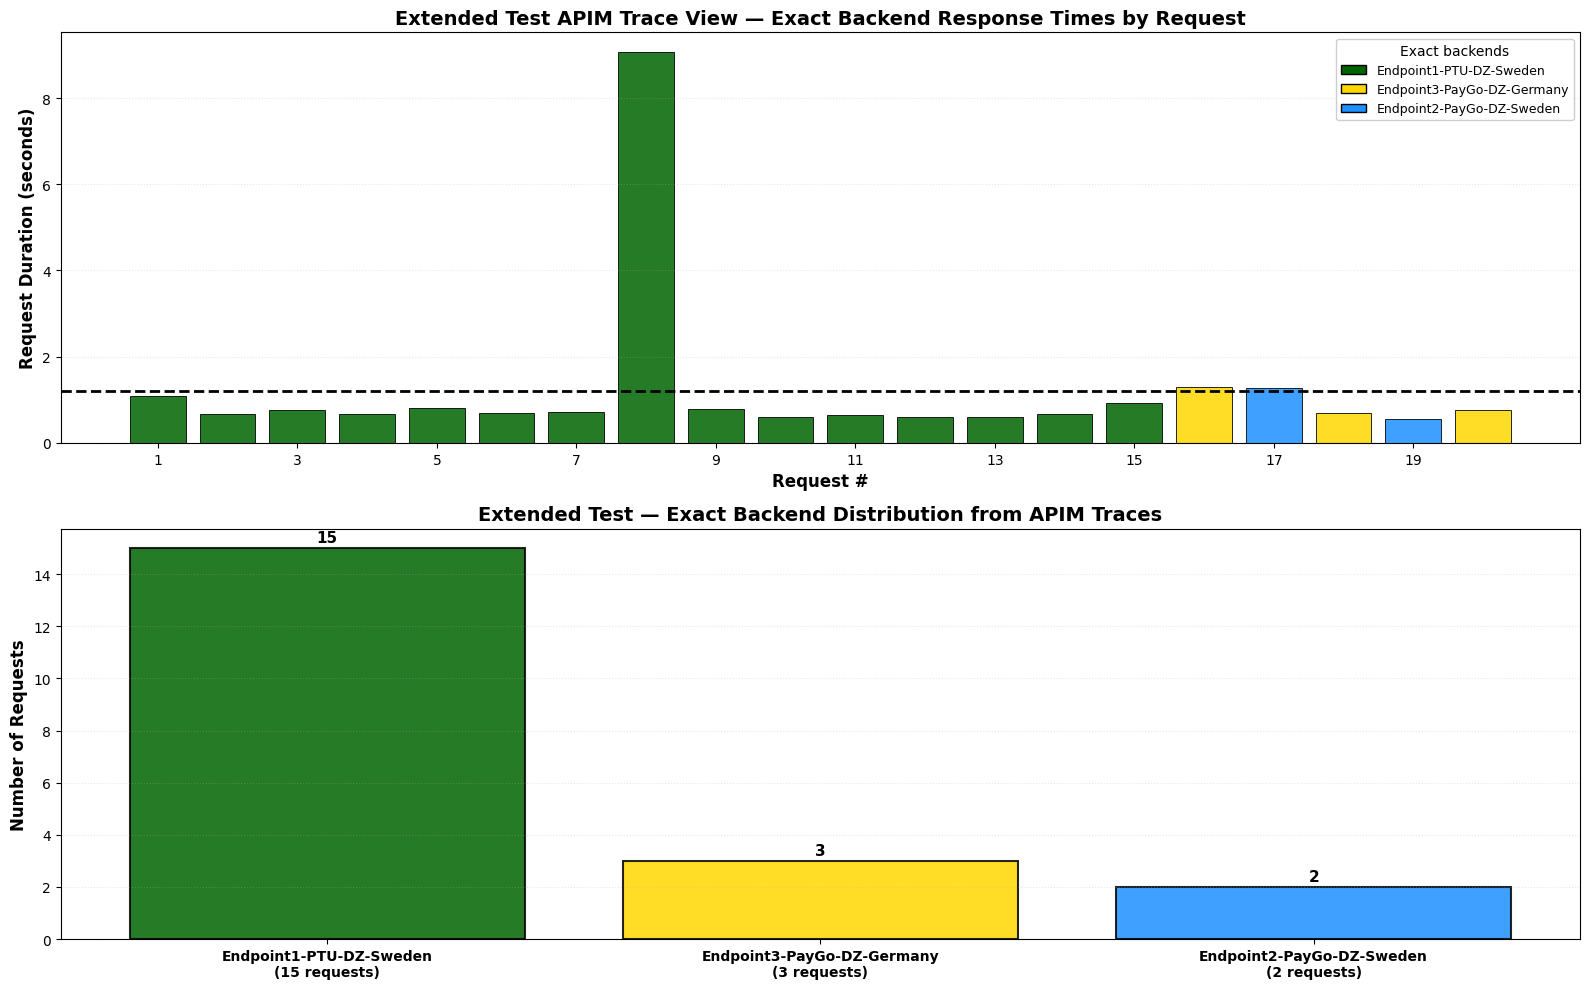


📊 EXTENDED TEST — EXACT BACKEND ATTRIBUTION FROM APIM TRACES
   • Endpoint1-PTU-DZ-Sweden: 15 requests (75.0%)
   • Endpoint3-PayGo-DZ-Germany: 3 requests (15.0%)
   • Endpoint2-PayGo-DZ-Sweden: 2 requests (10.0%)


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as pltRectangle

backend_diagnostics_df_extended = globals().get('backend_diagnostics_df_extended', pd.DataFrame())

if not backend_diagnostics_df_extended.empty:
    mpl.rcParams['figure.figsize'] = [16, 9]

    diagnostics_plot_df = backend_diagnostics_df_extended.copy().reset_index(drop=True)
    diagnostics_plot_df['Run'] = range(1, len(diagnostics_plot_df) + 1)

    fallback_index = 0
    for backend_name in diagnostics_plot_df['backendDisplayName'].drop_duplicates().tolist():
        if backend_name not in backend_color_map:
            backend_color_map[backend_name] = fallback_colors[fallback_index % len(fallback_colors)]
            fallback_index += 1

    bar_colors = [backend_color_map.get(name, '#BDBDBD') for name in diagnostics_plot_df['backendDisplayName']]
    backend_counts = diagnostics_plot_df['backendDisplayName'].value_counts()
    average_request_duration = diagnostics_plot_df['requestDurationSeconds'].dropna().mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.bar(
        diagnostics_plot_df['Run'],
        diagnostics_plot_df['requestDurationSeconds'],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85,
    )

    if pd.notna(average_request_duration):
        ax1.axhline(
            y=average_request_duration,
            color='black',
            linestyle='--',
            linewidth=2,
            label=f'Average: {average_request_duration:.3f}s',
        )

    ax1.set_title('Extended Test APIM Trace View — Exact Backend Response Times by Request', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Request #', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Request Duration (seconds)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, len(diagnostics_plot_df) + 1, 2 if len(diagnostics_plot_df) > 15 else 1))
    ax1.grid(axis='y', alpha=0.3, linestyle=':')

    legend_elements = [
        pltRectangle((0, 0), 1, 1, facecolor=backend_color_map[name], edgecolor='black', label=name)
        for name in diagnostics_plot_df['backendDisplayName'].drop_duplicates().tolist()
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, title='Exact backends')

    ax2.bar(
        range(len(backend_counts)),
        backend_counts.values,
        color=[backend_color_map.get(name, '#BDBDBD') for name in backend_counts.index],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.set_xticks(range(len(backend_counts)))
    ax2.set_xticklabels([f"{name}\n({count} requests)" for name, count in backend_counts.items()], fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Requests', fontsize=12, fontweight='bold')
    ax2.set_title('Extended Test — Exact Backend Distribution from APIM Traces', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle=':')

    for i, value in enumerate(backend_counts.values):
        ax2.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print('📊 EXTENDED TEST — EXACT BACKEND ATTRIBUTION FROM APIM TRACES')
    print("=" * 70)
    for backend_name, count in backend_counts.items():
        percentage = (count / len(diagnostics_plot_df)) * 100
        print(f"   • {backend_name}: {count} requests ({percentage:.1f}%)")
    print("=" * 70)
else:
    print('No exact extended trace data available. Run Step 8b first.')

---

## Step 9: Deterministic Failover Test — Endpoint 4 (Last-Resort Priority)

Simulate a complete failover scenario by temporarily reconfiguring the APIM backend pool so that **only Endpoint 4 (PayGo Global, Germany West Central)** is reachable — the Priority 3 last-resort backend — then running 5 targeted requests and verifying attribution from APIM traces.

- Mirrors the same capture and trace-attribution pattern as Steps 8, 8b, and 8c
- Gives definitive proof that Endpoint 4 can handle traffic end-to-end
- After verification, the original backend pool configuration is restored automatically in Step 9c (with a manual fallback section below)

> ⚠️ **Temporary override:** Step 9a modifies the live APIM backend pool for the duration of the test. The pool is restored automatically at the end of Step 9c. If the kernel is interrupted before Step 9c completes, use the manual restore fallback section below to return APIM to normal operation.

**Prerequisites:** Step 6 (deployment outputs) must have completed in this session.

**Step 9a** - Snapshot + override | **Step 9b** - Run 5 requests | **Step 9c** - Verify traces and auto-restore (optional chart + manual restore fallback below)

---

### Step 9a: Snapshot Current Pool and Apply Endpoint-4-Only Override

Read the current APIM inference backend pool and store it in `step10_original_pool_config` for rollback. Then reconfigure the pool so Endpoint 4 is the only backend, making it the forced and exclusive target for all requests sent during this test.

- Stores the unmodified pool definition so Step 9c can auto-restore (or the manual restore fallback can recover)
- Derives the Endpoint 4 backend name from `backend_host_to_name` (populated in Step 6)
- Confirms the override is active before exiting

Run this before Step 9b. The override remains in effect until Step 9c auto-restores the pool.

In [17]:
import json
import subprocess

APIM_API_VERSION = '2024-06-01-preview'
BACKEND_POOL_NAME = 'inference-backend-pool'

step10_original_pool_config = None
step10_pool_resource_uri = None
step10_endpoint4_name = None

if not apim_service_id:
    print('❌ apim_service_id is unavailable. Re-run Step 6 first.')
elif not backend_host_to_name:
    print('❌ backend_host_to_name is empty. Re-run Step 6 first.')
else:
    step10_pool_resource_uri = f'{apim_service_id}/backends/{BACKEND_POOL_NAME}?api-version={APIM_API_VERSION}'

    # --- Snapshot current pool ---
    get_result = subprocess.run(
        ['az', 'rest', '--method', 'get', '--uri', step10_pool_resource_uri, '-o', 'json'],
        capture_output=True, text=True,
    )
    if get_result.returncode != 0:
        print(f'❌ Failed to retrieve backend pool "{BACKEND_POOL_NAME}": {get_result.stderr}')
    else:
        step10_original_pool_config = json.loads(get_result.stdout)
        print(f'✅ Snapshot of "{BACKEND_POOL_NAME}" stored in step10_original_pool_config')
        services = step10_original_pool_config.get('properties', {}).get('pool', {}).get('services', [])
        print(f'   Original pool services ({len(services)}):')
        for svc in services:
            print(f'     • id={svc.get("id")} | priority={svc.get("priority")} | weight={svc.get("weight", "—")}')

        # --- Identify Endpoint 4 name from backend_host_to_name ---
        endpoint4_candidates = [
            name for name in backend_host_to_name.values()
            if 'endpoint4' in name.lower() or ('global' in name.lower() and 'germany' in name.lower())
        ]
        if endpoint4_candidates:
            step10_endpoint4_name = endpoint4_candidates[0]
        else:
            # Fallback: pick the service with the highest priority number (last-resort)
            services_sorted = sorted(services, key=lambda s: s.get('priority') or 0, reverse=True)
            last_resort_id = services_sorted[0].get('id', '') if services_sorted else ''
            step10_endpoint4_name = last_resort_id.split('/')[-1]

        print(f'\n🎯 Target backend for Endpoint 4: {step10_endpoint4_name}')

        # --- Build and apply Endpoint-4-only override ---
        override_body = {
            'properties': {
                'description': step10_original_pool_config.get('properties', {}).get('description', 'Load balancer for multiple inference endpoints'),
                'type': 'Pool',
                'pool': {
                    'services': [
                        {'id': f'/backends/{step10_endpoint4_name}', 'priority': 1}
                    ]
                }
            }
        }
        put_result = subprocess.run(
            [
                'az', 'rest',
                '--method', 'put',
                '--uri', step10_pool_resource_uri,
                '--body', json.dumps(override_body),
                '--headers', 'If-Match=*',
                '-o', 'json',
            ],
            capture_output=True, text=True,
        )
        if put_result.returncode != 0:
            print(f'❌ Failed to apply Endpoint-4-only override: {put_result.stderr}')
            step10_original_pool_config = None  # prevent rollback of a state we never changed
        else:
            applied = json.loads(put_result.stdout)
            applied_services = applied.get('properties', {}).get('pool', {}).get('services', [])
            print(f'\n✅ Override applied. Active pool services ({len(applied_services)}):')
            for svc in applied_services:
                print(f'     • id={svc.get("id")} | priority={svc.get("priority")}')
            print('\n⚠️  Only Endpoint 4 is now reachable via APIM. Run Step 9b, then Step 9c to verify and auto-restore.')

✅ Snapshot of "inference-backend-pool" stored in step10_original_pool_config
   Original pool services (4):
     • id=/subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagement/service/apim-nxghguyrkhpc2/backends/Endpoint1-PTU-DZ-Sweden | priority=1 | weight=—
     • id=/subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagement/service/apim-nxghguyrkhpc2/backends/Endpoint2-PayGo-DZ-Sweden | priority=2 | weight=50
     • id=/subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagement/service/apim-nxghguyrkhpc2/backends/Endpoint3-PayGo-DZ-Germany | priority=2 | weight=50
     • id=/subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagement/service/apim-nxghguyrkhpc2/backends/Endpoint4-PayGo-Global-Germany | priority=3 | weight=—

🎯 Target backend 

---

### Step 9b: Run Targeted Requests Against Endpoint 4

Send 5 sequential requests to the APIM gateway while the backend pool override is active. With only Endpoint 4 in the pool, every request must land on `Endpoint4-PayGo-Global-Germany`.

- Captures `x-ms-region`, endpoint hint headers, and `Apim-Trace-Id` using the same pattern as Step 9
- Stores results in `api_run_diagnostics_step10` for trace attribution in Step 9c

Run this after Step 9a, then run Step 9c.

In [20]:
import datetime
import json
import requests
import subprocess
import time

api_run_diagnostics_step10 = []

if not globals().get('step10_original_pool_config'):
    print('❌ Step 9a did not complete successfully. Run Step 9a before this cell.')
elif not apim_resource_gateway_url or not api_key:
    print('❌ Gateway URL or API key unavailable. Re-run Step 6 first.')
else:
    runs_step10 = 5
    sleep_time_ms_step10 = 200
    url_step10 = f"{apim_resource_gateway_url}/{inference_api_path}/openai/deployments/{models_config[0]['name']}/chat/completions?api-version={inference_api_version}"
    messages_step10 = {"messages": [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Say 'Endpoint 4 is reachable' and nothing else."}
    ]}


    # Obtain trace debug token
    trace_token_step10 = ''
    if apim_service_id:
        debug_creds_result = subprocess.run(
            [
                'az', 'rest', '--method', 'post',
                '--uri', f'{apim_service_id}/gateways/managed/listDebugCredentials?api-version=2023-05-01-preview',
                '--body', json.dumps({
                    'credentialsExpireAfter': 'PT1H',
                    'apiId': f'{apim_service_id}/apis/inference-api',
                    'purposes': ['tracing'],
                }),
                '-o', 'json',
            ],
            capture_output=True, text=True,
        )
        if debug_creds_result.returncode == 0:
            trace_token_step10 = (json.loads(debug_creds_result.stdout or '{}').get('token') or '').strip()

    if trace_token_step10:
        print('APIM trace capture: enabled')
    else:
        print('APIM trace capture: unavailable — Step 9c exact attribution will not be available')

    print(f'\n🚀 Sending {runs_step10} requests (Endpoint-4-only pool active)...\n')

    session_step10 = requests.Session()
    session_step10.headers.update({'api-key': api_key})
    if trace_token_step10:
        session_step10.headers.update({'Apim-Debug-Authorization': trace_token_step10})

    try:
        for i in range(runs_step10):
            print(f'▶️ Run {i+1}/{runs_step10}:')
            request_timestamp = datetime.datetime.now(datetime.UTC).isoformat().replace('+00:00', 'Z')
            start_time = time.time()
            response = session_step10.post(url_step10, json=messages_step10)
            response_time = time.time() - start_time
            print(f'⌚ {response_time:.2f} seconds')

            utils.print_response_code(response)

            trace_id = response.headers.get('Apim-Trace-Id', '')
            region = response.headers.get('x-ms-region', 'Unknown')
            print(f'x-ms-region: \x1b[1;32m{region}\x1b[0m')

            endpoint_hint = None
            for header_name in endpoint_hint_headers:
                header_value = response.headers.get(header_name)
                if header_value:
                    endpoint_hint = header_value
                    break

            if endpoint_hint:
                print(f'endpoint-hint: \x1b[1;36m{endpoint_hint}\x1b[0m')

            api_run_diagnostics_step10.append({
                'requestNumber': i + 1,
                'requestTimestamp': request_timestamp,
                'requestResultCode': str(response.status_code),
                'requestDurationSeconds': response_time,
                'region': region,
                'endpointHint': endpoint_hint or '',
                'traceId': trace_id,
                'requestUrl': url_step10,
            })

            if response.status_code == 200:
                data = json.loads(response.text)
                print(f'💬 {data.get("choices")[0].get("message").get("content")}\n')
            else:
                print(f'Error: {response.text}\n')

            time.sleep(sleep_time_ms_step10 / 1000)
    finally:
        session_step10.close()

    trace_count_step10 = sum(1 for run in api_run_diagnostics_step10 if run.get('traceId'))
    print(f'\n✅ {runs_step10} requests completed. Trace IDs captured: {trace_count_step10}/{runs_step10}')
    if trace_count_step10 == 0:
        print('⚠️  No trace IDs captured — Step 9c exact attribution will not be available.')
    print('\n▶️ Run Step 9c to confirm Endpoint 4 handled all requests and auto-restore APIM.')

APIM trace capture: enabled

🚀 Sending 5 requests (Endpoint-4-only pool active)...

▶️ Run 1/5:
⌚ 0.66 seconds
Response status: 200 - OK
x-ms-region: Germany West Central
💬 Endpoint 4 is reachable.

▶️ Run 2/5:
⌚ 0.45 seconds
Response status: 200 - OK
x-ms-region: Germany West Central
💬 Endpoint 4 is reachable.

▶️ Run 3/5:
⌚ 0.44 seconds
Response status: 200 - OK
x-ms-region: Germany West Central
💬 Endpoint 4 is reachable.

▶️ Run 4/5:
⌚ 0.44 seconds
Response status: 200 - OK
x-ms-region: Germany West Central
💬 Endpoint 4 is reachable.

▶️ Run 5/5:
⌚ 0.47 seconds
Response status: 200 - OK
x-ms-region: Germany West Central
💬 Endpoint 4 is reachable.


✅ 5 requests completed. Trace IDs captured: 5/5

▶️ Run Step 9c to confirm Endpoint 4 handled all requests and auto-restore APIM.


---

### Step 9c: Verify Endpoint 4 Attribution from APIM Traces

Query the APIM managed gateway traces for each Step 9b request and resolve the exact backend. With the override active every request should attribute to `Endpoint4-PayGo-Global-Germany`.

- Mirrors Step 8b — same `listTrace` API call and hostname-resolution logic
- Prints a confirmation summary showing that deterministic failover to Endpoint 4 was validated end-to-end
- **Auto-restores the original APIM backend pool by default** at the end of this cell (`auto_restore_pool_after_step10 = True`)

Run this after Step 9b. Optional chart and manual restore fallback sections are provided immediately below.

In [21]:
import json
import pandas as pd
import re
import subprocess

backend_diagnostics_df_step10 = pd.DataFrame()
api_run_diagnostics_step10_local = globals().get('api_run_diagnostics_step10', [])
# Defensive read — step10_endpoint4_name set by Step 9a; may be absent on kernel restart
_ep4_name = globals().get('step10_endpoint4_name')
auto_restore_pool_after_step10 = True
restore_status = 'NOT_ATTEMPTED'

print('\n' + '=' * 78)
print('STEP 9c PRE-CHECK')
print('=' * 78)
print(f"• Step 9a snapshot present: {'YES' if globals().get('step10_original_pool_config') else 'NO'}")
print(f"• Step 9a pool URI present: {'YES' if globals().get('step10_pool_resource_uri') else 'NO'}")
print(f"• Step 9b requests captured: {len(api_run_diagnostics_step10_local)}")
print(f"• Auto-restore after verification: {'ON' if auto_restore_pool_after_step10 else 'OFF'}")
print('=' * 78)

if not api_run_diagnostics_step10_local:
    print('No Step 9b request metadata available. Run Step 9b first.')
    restore_status = 'MANUAL_REQUIRED'
elif not apim_service_id:
    print('APIM service ID is unavailable. Re-run Step 6 first.')
    restore_status = 'MANUAL_REQUIRED'
elif not backend_host_to_name:
    print('Backend host mapping is empty. Re-run Step 6 to refresh deployment outputs.')
    restore_status = 'MANUAL_REQUIRED'
else:
    normalized_backend_host_to_name_step10 = {}
    for host_key, backend_name in backend_host_to_name.items():
        key = str(host_key).strip().lower().split(':')[0]
        if key:
            normalized_backend_host_to_name_step10[key] = backend_name

    tracked_backend_hosts_step10 = sorted(normalized_backend_host_to_name_step10.keys())
    tracked_backend_names_step10 = sorted({
        str(n).strip() for n in normalized_backend_host_to_name_step10.values() if str(n).strip()
    })

    def fetch_trace_step10(trace_id):
        if not trace_id:
            return None
        result = subprocess.run(
            [
                'az', 'rest', '--method', 'post',
                '--uri', f'{apim_service_id}/gateways/managed/listTrace?api-version=2023-05-01-preview',
                '--body', json.dumps({'traceId': trace_id}),
                '-o', 'json',
            ],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            return None
        try:
            return json.loads(result.stdout or '{}')
        except json.JSONDecodeError:
            return None

    def resolve_host_step10(trace_payload):
        if not trace_payload:
            return ''
        trace_text = json.dumps(trace_payload).lower()
        for host in tracked_backend_hosts_step10:
            if host in trace_text:
                return host
        url_match = re.search(r'https://([a-z0-9.-]+)', trace_text)
        if url_match:
            candidate = url_match.group(1).split(':')[0]
            if candidate in normalized_backend_host_to_name_step10:
                return candidate
        return ''

    def resolve_name_step10(trace_payload):
        if not trace_payload:
            return 'Unknown backend'
        host = resolve_host_step10(trace_payload)
        if host:
            return normalized_backend_host_to_name_step10.get(host, 'Unknown backend')
        trace_text = json.dumps(trace_payload).lower()
        for name in tracked_backend_names_step10:
            if name.lower() in trace_text:
                return name
        return 'Unknown backend'

    def restore_pool_from_step10_snapshot():
        snapshot = globals().get('step10_original_pool_config')
        pool_uri = globals().get('step10_pool_resource_uri')
        pool_name = globals().get('BACKEND_POOL_NAME', 'inference-backend-pool')

        if not snapshot:
            print('⚠️ Auto-restore skipped: no Step 9 snapshot found in memory.')
            return False
        if not pool_uri:
            print('⚠️ Auto-restore skipped: pool URI is missing in memory.')
            return False

        original_props = snapshot.get('properties', {})
        restore_body = {
            'properties': {
                'description': original_props.get('description', 'Load balancer for multiple inference endpoints'),
                'type': 'Pool',
                'pool': {
                    'services': original_props.get('pool', {}).get('services', [])
                }
            }
        }

        restore_result = subprocess.run(
            [
                'az', 'rest',
                '--method', 'put',
                '--uri', pool_uri,
                '--body', json.dumps(restore_body),
                '--headers', 'If-Match=*',
                '-o', 'json',
            ],
            capture_output=True, text=True,
        )
        if restore_result.returncode != 0:
            print(f'❌ Auto-restore failed: {restore_result.stderr}')
            return False

        restored = json.loads(restore_result.stdout)
        restored_services = restored.get('properties', {}).get('pool', {}).get('services', [])
        print(f'✅ Auto-restore succeeded for backend pool "{pool_name}".')
        print(f'   Active pool services ({len(restored_services)}):')
        for svc in restored_services:
            print(f'     • id={svc.get("id")} | priority={svc.get("priority")} | weight={svc.get("weight", "—")}')

        globals()['step10_original_pool_config'] = None
        return True

    trace_rows_step10 = []
    for run in [r for r in api_run_diagnostics_step10_local if r.get('traceId')]:
        payload = fetch_trace_step10(run.get('traceId'))
        trace_rows_step10.append({
            'requestNumber': run.get('requestNumber'),
            'requestTimestamp': run.get('requestTimestamp'),
            'backendDisplayName': resolve_name_step10(payload),
            'backendHost': resolve_host_step10(payload),
            'requestResultCode': run.get('requestResultCode', ''),
            'requestDurationSeconds': run.get('requestDurationSeconds'),
            'clientObservedRegion': run.get('region', 'Unknown'),
            'traceId': run.get('traceId', ''),
        })

    if not trace_rows_step10:
        print('No APIM trace IDs were captured in Step 9b.')
        print('Re-run Step 9b with trace capture enabled, then rerun this cell.')
    else:
        backend_diagnostics_df_step10 = pd.DataFrame(trace_rows_step10).sort_values('requestNumber').reset_index(drop=True)

        display_columns_step10 = [
            'requestNumber', 'requestTimestamp', 'backendDisplayName',
            'backendHost', 'clientObservedRegion', 'requestResultCode',
            'requestDurationSeconds', 'traceId',
        ]
        display(backend_diagnostics_df_step10[display_columns_step10])

        counts_step10 = backend_diagnostics_df_step10['backendDisplayName'].value_counts()
        total_step10 = len(backend_diagnostics_df_step10)

        print('\n' + '=' * 70)
        print('📊 STEP 9 FAILOVER TEST — EXACT BACKEND ATTRIBUTION FROM APIM TRACES')
        print('=' * 70)
        for name, count in counts_step10.items():
            pct = (count / total_step10) * 100
            is_endpoint4 = 'endpoint4' in name.lower() or ('global' in name.lower() and 'germany' in name.lower())
            marker = '✅' if is_endpoint4 else '⚠️'
            print(f'   {marker} {name}: {count} requests ({pct:.1f}%)')
        print('=' * 70)

        endpoint4_count = counts_step10.get(_ep4_name, 0) if _ep4_name else 0
        if _ep4_name and endpoint4_count == total_step10:
            print(f'\n✅ CONFIRMED: All {total_step10} requests routed exclusively to {_ep4_name}.')
            print('   Deterministic failover to Endpoint 4 validated end-to-end.')
        else:
            unresolved = (backend_diagnostics_df_step10['backendDisplayName'] == 'Unknown backend').sum()
            if _ep4_name:
                print(f'\n⚠️  Expected all {total_step10} requests on Endpoint 4, but {endpoint4_count}/{total_step10} matched.')
            else:
                print(f'\n⚠️  Could not confirm Endpoint 4 name (Step 9a may not have run). Check the table above.')
            if unresolved > 0:
                print(f'   {unresolved} trace(s) could not be resolved — host may not appear in trace text.')
            print('   Check that Step 9a override was applied before running Step 9b.')

    if auto_restore_pool_after_step10:
        print('\n🔁 Auto-restore is enabled. Restoring original APIM backend pool now...')
        restored_ok = restore_pool_from_step10_snapshot()
        if restored_ok:
            restore_status = 'SUCCESS'
            print('✅ Environment returned to initial routing state. You can safely rerun previous steps.')
        else:
            restore_status = 'FAILED'
            print('⚠️ Auto-restore did not complete. Run the manual restore fallback section below.')
    else:
        restore_status = 'MANUAL_REQUIRED'
        print('\n⏸️ Auto-restore is disabled (`auto_restore_pool_after_step10 = False`).')
        print('▶️ Run the manual restore fallback section below to restore the original APIM backend pool configuration.')

print('\n' + '=' * 78)
print(f'RESTORE STATUS: {restore_status}')
if restore_status == 'SUCCESS':
    print('✅ APIM routing is back to the initial configuration.')
elif restore_status == 'FAILED':
    print('❌ APIM routing may still be forced to Endpoint 4. Run the manual restore fallback section below immediately.')
elif restore_status == 'MANUAL_REQUIRED':
    print('⚠️ APIM routing requires manual restore. Run the manual restore fallback section below.')
else:
    print('ℹ️ Restore was not attempted in this run.')
print('=' * 78)


STEP 9c PRE-CHECK
• Step 9a snapshot present: YES
• Step 9a pool URI present: YES
• Step 9b requests captured: 5
• Auto-restore after verification: ON


,requestNumber,requestTimestamp,backendDisplayName,backendHost,clientObservedRegion,requestResultCode,requestDurationSeconds,traceId
0,1,2026-04-09T20:40:02.781023Z,Endpoint4-PayGo-Global-Germany,endpoint4-paygo-global-germany-nxghguyrkhpc2.c...,Germany West Central,200,0.661636,733ff9b089f0432db81675ea9721ee7a
1,2,2026-04-09T20:40:03.643271Z,Endpoint4-PayGo-Global-Germany,endpoint4-paygo-global-germany-nxghguyrkhpc2.c...,Germany West Central,200,0.447164,80bbee0d856942abbb06449ea571bc40
2,3,2026-04-09T20:40:04.290864Z,Endpoint4-PayGo-Global-Germany,endpoint4-paygo-global-germany-nxghguyrkhpc2.c...,Germany West Central,200,0.444547,17f45d50a91e47f0bbf29abe0d1d32b5
3,4,2026-04-09T20:40:04.935798Z,Endpoint4-PayGo-Global-Germany,endpoint4-paygo-global-germany-nxghguyrkhpc2.c...,Germany West Central,200,0.438704,b88d5be5099442bbaf4fcf2186bc9ccb
4,5,2026-04-09T20:40:05.574882Z,Endpoint4-PayGo-Global-Germany,endpoint4-paygo-global-germany-nxghguyrkhpc2.c...,Germany West Central,200,0.471278,dab269ce418c454f825f1616159a33fc



📊 STEP 9 FAILOVER TEST — EXACT BACKEND ATTRIBUTION FROM APIM TRACES
   ✅ Endpoint4-PayGo-Global-Germany: 5 requests (100.0%)

✅ CONFIRMED: All 5 requests routed exclusively to Endpoint4-PayGo-Global-Germany.
   Deterministic failover to Endpoint 4 validated end-to-end.

🔁 Auto-restore is enabled. Restoring original APIM backend pool now...
✅ Auto-restore succeeded for backend pool "inference-backend-pool".
   Active pool services (4):
     • id=/subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagement/service/apim-nxghguyrkhpc2/backends/Endpoint1-PTU-DZ-Sweden | priority=1 | weight=—
     • id=/subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagement/service/apim-nxghguyrkhpc2/backends/Endpoint2-PayGo-DZ-Sweden | priority=2 | weight=50
     • id=/subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-specs-to-foundry/providers/Microsoft.ApiManagem

---

###  Visualize Failover Backend Attribution (After Step 9c)

Visualize the exact backend assignments returned by APIM traces for the Endpoint 4 failover test.

- Uses `backend_diagnostics_df_step10` built in Step 9c
- Shows response times per request (top) and backend distribution (bottom) — same chart format as Steps 7c and 9c
- Confirms all 5 requests were routed exclusively to Endpoint 4

Run this after Step 9c completes.


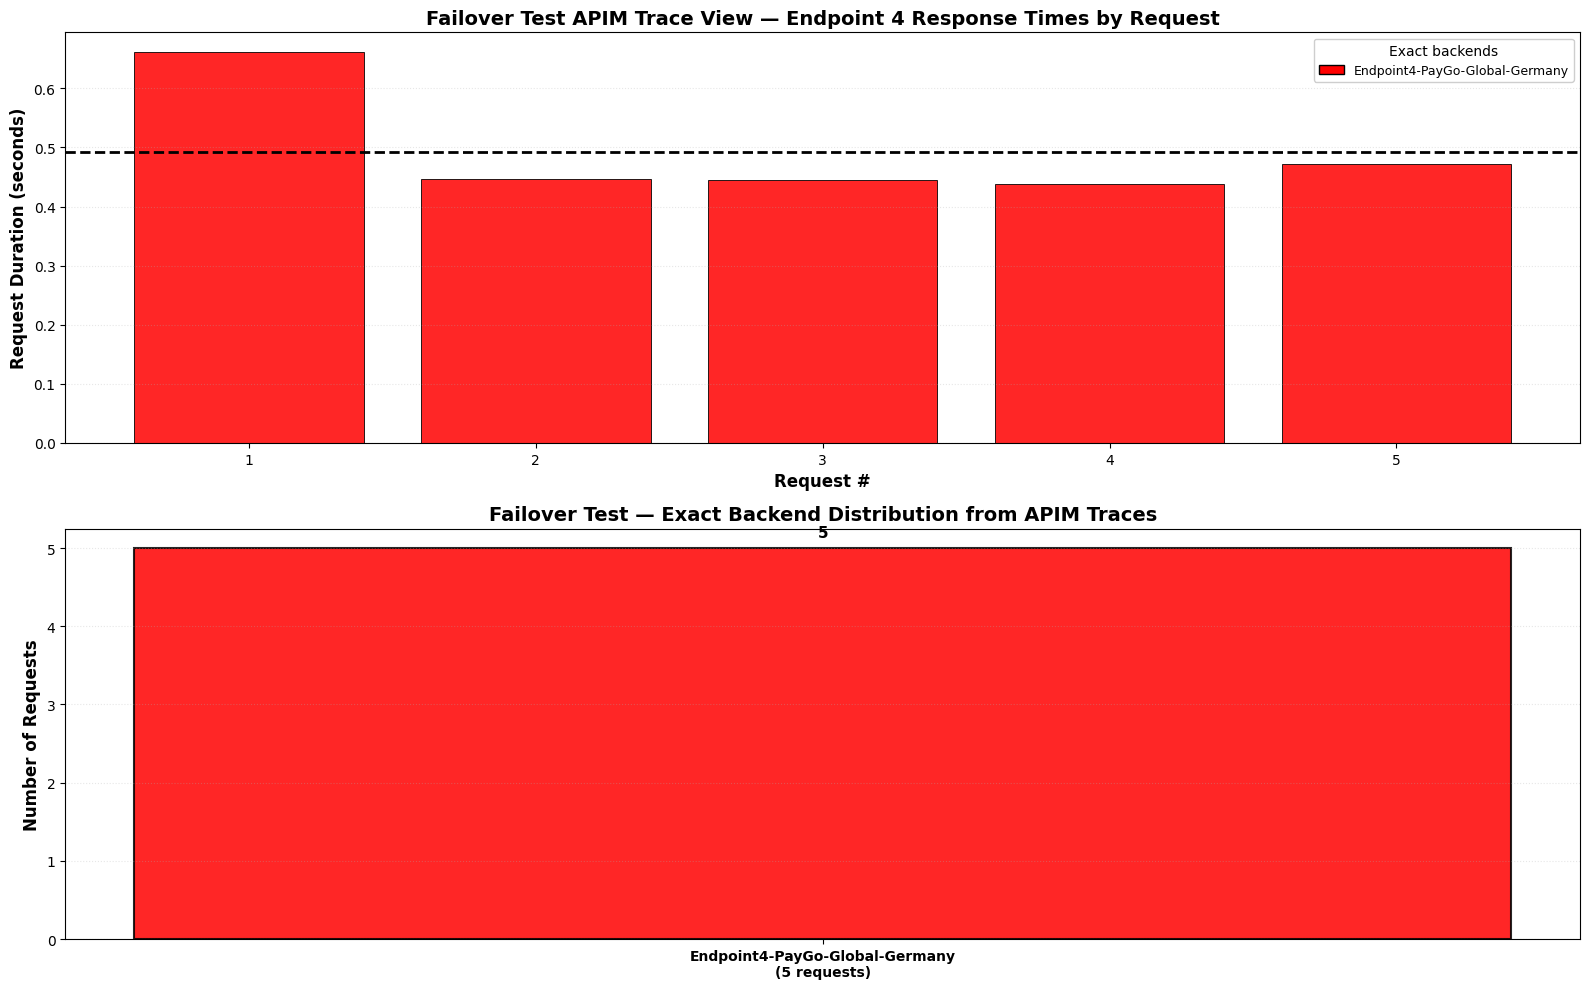


📊 FAILOVER TEST — EXACT BACKEND ATTRIBUTION FROM APIM TRACES
   • Endpoint4-PayGo-Global-Germany: 5 requests (100.0%)


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as pltRectangle

backend_diagnostics_df_step10 = globals().get('backend_diagnostics_df_step10', pd.DataFrame())

if not backend_diagnostics_df_step10.empty:
    mpl.rcParams['figure.figsize'] = [16, 9]

    diagnostics_plot_df = backend_diagnostics_df_step10.copy().reset_index(drop=True)
    diagnostics_plot_df['Run'] = range(1, len(diagnostics_plot_df) + 1)

    fallback_index = 0
    for backend_name in diagnostics_plot_df['backendDisplayName'].drop_duplicates().tolist():
        if backend_name not in backend_color_map:
            backend_color_map[backend_name] = fallback_colors[fallback_index % len(fallback_colors)]
            fallback_index += 1

    bar_colors = [backend_color_map.get(name, '#BDBDBD') for name in diagnostics_plot_df['backendDisplayName']]
    backend_counts = diagnostics_plot_df['backendDisplayName'].value_counts()
    average_request_duration = diagnostics_plot_df['requestDurationSeconds'].dropna().mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.bar(
        diagnostics_plot_df['Run'],
        diagnostics_plot_df['requestDurationSeconds'],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85,
    )

    if pd.notna(average_request_duration):
        ax1.axhline(
            y=average_request_duration,
            color='black',
            linestyle='--',
            linewidth=2,
            label=f'Average: {average_request_duration:.3f}s',
        )

    ax1.set_title('Failover Test APIM Trace View — Endpoint 4 Response Times by Request', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Request #', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Request Duration (seconds)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, len(diagnostics_plot_df) + 1, 2 if len(diagnostics_plot_df) > 15 else 1))
    ax1.grid(axis='y', alpha=0.3, linestyle=':')

    legend_elements = [
        pltRectangle((0, 0), 1, 1, facecolor=backend_color_map[name], edgecolor='black', label=name)
        for name in diagnostics_plot_df['backendDisplayName'].drop_duplicates().tolist()
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, title='Exact backends')

    ax2.bar(
        range(len(backend_counts)),
        backend_counts.values,
        color=[backend_color_map.get(name, '#BDBDBD') for name in backend_counts.index],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.set_xticks(range(len(backend_counts)))
    ax2.set_xticklabels([f"{name}\n({count} requests)" for name, count in backend_counts.items()], fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Requests', fontsize=12, fontweight='bold')
    ax2.set_title('Failover Test — Exact Backend Distribution from APIM Traces', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle=':')

    for i, value in enumerate(backend_counts.values):
        ax2.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print('📊 FAILOVER TEST — EXACT BACKEND ATTRIBUTION FROM APIM TRACES')
    print("=" * 70)
    for backend_name, count in backend_counts.items():
        percentage = (count / len(diagnostics_plot_df)) * 100
        print(f"   • {backend_name}: {count} requests ({percentage:.1f}%)")
    print("=" * 70)
else:
    print('No exact failover trace data available. Run Step 9c first.')


---

### Optional: Restore Original APIM Backend Pool (Manual Fallback)

Restore the full backend pool configuration — all four endpoints at their correct priorities and weights — using the snapshot taken in Step 9a. This removes the Endpoint-4-only override and returns APIM to normal priority-based load balancing.

Use this cell when:
- Auto-restore in Step 9c was disabled, or
- Step 9c failed/interrupted before restore completed, or
- You want to force a manual restore verification pass

> ⚠️ If the kernel was restarted between Step 9a and this cell, restore manually via **Azure Portal → APIM → Backends → inference-backend-pool**.

In [ ]:
import json
import subprocess

# Defensive reads — safe if kernel was restarted after Step 9a ran
step10_original_pool_config = globals().get('step10_original_pool_config')
step10_pool_resource_uri = globals().get('step10_pool_resource_uri')
_pool_name = globals().get('BACKEND_POOL_NAME', 'inference-backend-pool')

if not step10_original_pool_config:
    print('⚠️  No snapshot found in step10_original_pool_config.')
    print('   The pool may not have been modified, or a previous restore already ran.')
elif not step10_pool_resource_uri:
    print('❌ Pool resource URI not set. Re-run Step 9a to re-establish the snapshot and retry.')
else:
    # Reconstruct a clean restore body — only the fields APIM accepts for a Pool PUT.
    # Avoids sending read-only fields (provisioningState, resourceState, etc.) from the GET snapshot.
    original_props = step10_original_pool_config.get('properties', {})
    restore_body = {
        'properties': {
            'description': original_props.get('description', 'Load balancer for multiple inference endpoints'),
            'type': 'Pool',
            'pool': {
                'services': original_props.get('pool', {}).get('services', [])
            }
        }
    }
    restore_result = subprocess.run(
        [
            'az', 'rest',
            '--method', 'put',
            '--uri', step10_pool_resource_uri,
            '--body', json.dumps(restore_body),
            '--headers', 'If-Match=*',
            '-o', 'json',
        ],
        capture_output=True, text=True,
    )
    if restore_result.returncode != 0:
        print(f'❌ Restore failed: {restore_result.stderr}')
        print('   Retry this cell, or restore manually via Azure Portal → APIM → Backends → inference-backend-pool.')
    else:
        restored = json.loads(restore_result.stdout)
        restored_services = restored.get('properties', {}).get('pool', {}).get('services', [])
        print(f'✅ Backend pool "{_pool_name}" restored successfully.')
        print(f'   Active pool services ({len(restored_services)}):')
        for svc in restored_services:
            print(f'     • id={svc.get("id")} | priority={svc.get("priority")} | weight={svc.get("weight", "—")}')
        step10_original_pool_config = None  # prevent accidental re-restore
        print('\n✅ APIM is back to normal priority-based routing across all four endpoints.')

---

### Step 9 Complete

The deterministic failover test is done and the original APIM configuration is restored. The complete routing picture across all three phases is now demonstrated:

| Phase | Steps | What you proved |
|---|---|---|
| **Baseline** | 7, 7a, 7b, 7c | Steady-state: Endpoint 1 handles all 5 requests at Priority 1 |
| **Extended** | 8, 8a, 8b, 8c | At scale: Endpoints 1–3 participate as Priority 1 saturates under 20 requests |
| **Failover** | 9, 9a, 9b, 9c | Deterministic: Endpoint 4 (last-resort) is reachable and fully operational |

Continue to **Step 11** for a detailed breakdown of the APIM retry policy that makes this routing transparent to callers.

---

## Step 11: Understand the APIM Policy

The APIM **retry policy** transparently intercepts HTTP 429 and 503 responses and reroutes requests to the next available backend in the pool. This ensures callers never see a rate-limit error unless **all** backends are exhausted.

### APIM Policy XML

The policy is applied to the inference API and uses APIM's **backend pool feature** for priority-based routing:

```xml
<policies>
    <inbound>
        <base />
        <set-backend-service backend-id="{backend-id}" />
    </inbound>
    <backend>
        <!--Set count to one less than the number of backends in the pool to try
            all backends until the backend pool is temporarily unavailable.-->
        <retry count="2" interval="0" first-fast-retry="true"
               condition="@(context.Response.StatusCode == 429 ||
                            context.Response.StatusCode == 503)">
            <!--Switch back to same backend pool which will have automatically
                removed the faulty backend -->
            <set-backend-service backend-id="{backend-id}" />
            <forward-request buffer-request-body="true" />
        </retry>
    </backend>
    <outbound>
        <base />
    </outbound>
    <on-error>
        <base />
        <choose>
            <!--Return a generic error that does not reveal backend pool details.-->
            <when condition="@(context.Response.StatusCode == 503)">
                <return-response>
                    <set-status code="503" reason="Service Unavailable" />
                </return-response>
            </when>
        </choose>
    </on-error>
</policies>
```

### Policy Behavior

| Policy Element | What It Does |
|---|---|
| `set-backend-service` (inbound) | Directs request to the named backend pool instead of individual backends |
| `retry` (backend, count=2) | On HTTP 429 or 503, retries up to 2 times; APIM picks the next available backend by priority |
| `buffer-request-body="true"` | Buffers the request body so it can be replayed to the next backend |
| `on-error choose` | Returns a sanitised 503; caller never sees backend names or URLs |

---

## Step 12: Clean Up Resources

When finished with the lab, remove all deployed resources to avoid Azure charges.

The source lab provides a separate cleanup notebook:
[clean-up-resources.ipynb](https://github.com/Azure-Samples/AI-Gateway/blob/main/labs/backend-pool-load-balancing/clean-up-resources.ipynb)

Alternatively, delete the entire resource group:

```bash
az group delete --name lab-backend-pool-load-balancing --yes
```

This removes:
- AI Foundry projects and accounts
- APIM instance
- All associated networking and compute resources

---

## Troubleshooting

### Deployment errors: "Project name is invalid"

- AI Foundry project names must be **2–64 characters**, containing only **alphanumeric characters, underscores, and hyphens**.
- The default project name has been shortened to `ghspeckit-to-foundry` in Step 3. If you customized it, use a simpler name like `aiproject` or `ai_demo`.
- Verify in Step 3: `print(f"AI Foundry Project: {foundry_project_name}")`

### Deployment errors: "IfMatchPreconditionFailed"

- This indicates a resource conflict from a previous failed or incomplete deployment.
- **Solution**: delete the resource group and redeploy:
  ```bash
  az group delete --name rg-gh-spec-kit-to-foundry-mission-critical --yes
  ```
- Then re-run Step 5 to deploy fresh.
- Alternatively, wait a few minutes and retry Step 5 — Azure may self-heal the conflict.

### Deployment stuck / times out

- Basicv2 APIM typically completes in ~2 minutes. If stuck beyond 10 minutes, check the Azure Portal under **Resource group → Deployments** for live status.
- If deployment fails at the APIM step, verify your subscription has capacity for the `Basicv2` SKU in your region.

### Model deployment errors

- Verify `gpt-4o-mini` (version `2024-07-18`) is available in **both regions** at the [Azure OpenAI models page](https://learn.microsoft.com/azure/ai-services/openai/concepts/models).
- `GlobalStandard` SKU requires quota in each region. Check per-region quota:
  ```bash
  for loc in swedencentral germanywestcentral; do
    echo "=== $loc ==="
    az cognitiveservices usage list --location $loc -o table 2>/dev/null | grep -i gpt
  done
  ```

### HTTP 401 on test calls

- The APIM subscription key is passed via the `api-key` header. Confirm the key hasn't been regenerated.
- Double-check `apim_resource_gateway_url` doesn't end with a trailing slash.

### HTTP 503 on test calls

- All four backends are exhausted simultaneously. With `capacity: 1` (~1k TPM each), rapid bursts drain the entire pool.
- Increase `sleep_time_ms` (e.g., to `500`) or wait a minute for quota to reset, then re-run the test cell.
- Increase `capacity` in `models_config` and re-run the deployment cell.

### Application Insights shows only region-level attribution

- In this lab, Application Insights may show request telemetry and `x-ms-region` without exposing the exact backend host or backend ID.
- That means App Insights can be useful for timing and regional confirmation, but not always for distinguishing two backends in the same region.
- Use Step 7b and Step 8b as the authoritative exact-attribution steps because they read APIM managed gateway traces directly.

### APIM trace IDs are missing

- Exact backend attribution in Steps 7b and 9b depends on the `Apim-Trace-Id` response header captured during Step 7 or Step 8.
- If no trace IDs were captured, rerun the request step first, then rerun the matching attribution step.
- Your Azure identity must be allowed to call the APIM managed gateway trace APIs used to obtain debug credentials and trace payloads.

### Kernel failed to start

This happens when the `.venv` was deleted or corrupted. Re-run the Step 1 setup cell to recreate it, then reload VS Code (`Ctrl+Shift+P` → *Developer: Reload Window*).

### x-ms-region header missing

This header is set by each Azure OpenAI backend. If missing, the request may not have reached the backend pool. Check the APIM logs in Azure Portal for details.

---

## Further Reading

- [APIM Backend Pools Documentation](https://learn.microsoft.com/azure/api-management/backends?tabs=bicep)
- [Azure OpenAI Models and Availability](https://learn.microsoft.com/azure/ai-services/openai/concepts/models)
- [APIM Retry Policy Reference](https://learn.microsoft.com/azure/api-management/retry-policy)
- [APIM Managed Identity Authentication](https://learn.microsoft.com/azure/api-management/authentication-managed-identity-policy)
- [AI Gateway Lab Catalogue](https://github.com/Azure-Samples/AI-Gateway/tree/main/labs)
- [Azure AI Foundry Deployment Types](https://learn.microsoft.com/en-us/azure/foundry/foundry-models/concepts/deployment-types)
- [Azure API Management Tier Features](https://learn.microsoft.com/en-us/azure/api-management/api-management-features)

---

## Notes

- This notebook is a faithful conversion of the [source lab guide](https://github.com/Azure-Samples/AI-Gateway/blob/main/labs/backend-pool-load-balancing/backend-pool-load-balancing.ipynb).
- All code cells can run in sequence; cell-to-cell state is preserved via Python variables.
- This repository includes local Bicep modules and shared utilities so no external clone is required for this scenario.
- Exact backend attribution in this notebook now comes from APIM managed gateway traces.
- Application Insights remains useful for supporting diagnostics, but in this scenario it may still be region-only rather than endpoint-exact.
- Questions or issues? See the [main AI-Gateway repo](https://github.com/Azure-Samples/AI-Gateway) or open an issue there.